In [4]:
install.packages("ggplot2", dependencies = T)

Installing package into ‘/home/juan/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

also installing the dependencies ‘sass’, ‘bslib’, ‘htmlTable’, ‘rmarkdown’, ‘htmlwidgets’, ‘fs’, ‘systemfonts’, ‘textshaping’, ‘pkgload’, ‘s2’, ‘units’, ‘Hmisc’, ‘profvis’, ‘quarto’, ‘ragg’, ‘roxygen2’, ‘sf’, ‘svglite’, ‘testthat’, ‘vdiffr’


Warning message in install.packages("ggplot2", dependencies = T):
“installation of package ‘fs’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = T):
“installation of package ‘systemfonts’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = T):
“installation of package ‘s2’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = T):
“installation of package ‘units’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = T):
“installation of package ‘sass’ had non-zero exit status”
Warning message in install.packages

In [15]:
source("/home/juan/Documentos/Rfunj/arranque_notebook.R")

In [16]:
# Borra consola, variables y funciones definidas en el entorno Global
cat("\014")
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());

In [17]:
#carga librerías
library("lattice")
library("ggplot2")
library("latex2exp")
library("pracma")
suppressMessages(library("crayon"))

#si no están instaladas, usar: install.packages("crayon", dependencies = T)
#obvio, cambiar crayon por las librerías que necesiten

#tamaño de la figura en Jupyter
fig <- function(width, heigth) {
    options(repr.plot.width = width, repr.plot.height = heigth)
}
fig(26,14);

In [19]:
#tema de graficación
library("ggplot2")
temajuan <- theme(
  legend.position = c(0.14, 0.80),
  legend.background = element_blank(),
  legend.title = element_text(size = 22),
  legend.box = "horizontal",
  legend.direction = "vertical",
  plot.title = element_text(size = 18),
  #legend.key.height = unit(0.1,"snpc"),
  legend.key.width  = unit(0.125,"snpc"),
  #legend.box.spacing = unit(0.1,"snpc"),
  legend.key = element_blank(),
  legend.spacing.x = unit(10, "pt"),
  legend.text = element_text(size = 24, margin = margin(t = 0, r= 5,b = 0, l = 3, unit = "pt")),
  axis.line = element_line(linewidth = 0.5, lineend = "square"),
  axis.title = element_text(size = 24),
  axis.text.x = element_text(size = 18, colour = "black", angle = 0,  vjust = 1),
  axis.text.y = element_text(size = 18, colour = "black"),
  axis.ticks = element_line(linewidth = 1, colour = "black"),
  panel.border = element_rect(linewidth = 1, fill = NA)
)  

# Calibrando un Inclinómetro digital

## Calibrar es:


 * Comparar una ***serie de medidas*** (en este caso, del acelerómetro) con otra serie de medidas (que denominamos **patrón de medida**), a fines de poder usar la *primer serie de medidas* para futuras mediciones, pero empleando el instrumento calibrado.
 * Habitualmente la señal es de distinta magnitud que el patrón (aquí usaremos la señal que mide la gravedad en tres ejes del teléfono como ***proxy*** del ángulo respecto de la horizontal).
 * Cuando se utiliza un ***rango*** de la señal, lo que buscamos es una ***curva de calibración***, es decir, una función que nos entregue la medida buscada una vez obtenida la señal.

# Instrumentos de medida

## 1. Regla ó cinta métrica

Para estimar ángulos mediremos los catetos, como se muestra en la foto. Otra opción es medir un cateto (el opuesto por ejemplo) y medir la madera (la hipotenusa), lo cual conviene mucho (no es necesario medir dos veces para cada ángulo).

Los ángulos que salgan de estas medidas serán el ***patrón de ángulos*** (es veredad que ***patrón lo que se dice patrón...no son***, pero son algo que conocemos bastante bien, y con lo que estamos familiarizados.

Si alguien prefiere medir ángulos con un gran transportador o lo que sea, perfecto.

<img src= "./graf/plano.png" width = "600px"/>

* Pegamos con cinta transparente las reglas.
* Nos aseguramos de encajar bien los orígenes.
* Pegamos nuestro teléfono (con cinta) a un pedazo de madera.

Detalles: elija el pedazo de madera en función de las reglas de las que disponga.



## 2. Acelerómetro
El teléfono cuenta con un acelerómetro de tres ejes. Cuando el teléfono está en reposo, los tres ejes del acelerómetro ***descomponen*** la gravedad en una base ortonormal, como las del álgebra. Esta descomposición es la que permite que el software del teléfono rote la pantalla cuando el teléfono es movido por el usuario.

Es justamente esta descomposición la que utilizaremos para ***estimar*** el ángulo respecto de la horizontal del teléfono, lo que nos permitirá medir ángulos en un futuro.

Ya sabemos del Labo 1 que:

1. El acelerómetro (como cualquier instrumento) no mide siempre el mismo valor: el ruido está presente en la medida.

1. El acelerómetro mide la gravedad cuando está en reposo (para medir aceleraciones iguales a cero, tiene que estar en caída libre): mide desde un sistema de referencia no inercial, básicamente por la forma en la que mide (pensarlo detenidamente).

1. Cualquier vibración afecta al acelerómetro y dispara los valores registrados, por lo que intentemos tener el teléfono lo más quieto posible y tener una demora de unos segundos desde que apretemos el botón y el inicio de la medida (esto es posible con Phyfox, pero no se si con el software indicado en la guía).

<img src="./graf/acelerometrosem.jpg" width="750" />

# Modelos (cuentas para obtener el ángulo de inclinación)

## 1. Medidas de Longitud: trigonometría
Si usan un formato como el que está en la imagen, lo que tenemos es:

* Medidas del Cateto Opuesto (CO en adelante).

* Medidas del Cateto Adyacente (CA en adelante).

Podemos calcular la tangente del ángulo $\theta$ formado por la madera con el teléfono como:

$$
tan(\theta) = \frac{CO}{CA} \Longrightarrow \theta = arctan\Big(\frac{CO}{CA}\Big)
$$

Otra forma es:

* Medida del Cateto Opuesto (CO)
* Medida de la Hipotenusa (H)

$$
sen(\theta) = \frac{CO}{H} \Longrightarrow \theta = arcsen\Big(\frac{CO}{H}\Big)
$$

Si es por practicidad, la segunda forma es mejor, porque sólo tenemos que medir la hipotenusa (la madera) una vez$^{(1)}$.

(1) Yo fuí medio *gilastrún* y medí CO y CA, así es que las cuentas de este apunte están con este método.

## 2. Medidas con el acelerómetro

La idea básica es que tendremos una medida de ***referencia*** de la aceleración de la gravedad en posición ***horizontal*** del teléfono pegado a la madera. A esta medida la bautizamos $\vec{g_{e_{i,\; \theta  \, = \, 0}}}\;\;\; = \vec{g_h}$

Luego tenemos una medida para cada ángulo $\theta_i$, que bautizamos $\vec{g}_{e'_{i\, \,, \theta_i}} = \vec{g}_{\theta_i}$

*Sólo para aclarar*: estamos midiendo el ***mismo vector*** $\vec{g}$, pero con la base ortonormal rotada. Las cuentas se pueden poner complicadas, pero es posible mostrar que ***rotar la base*** es lo mismo que ***considerar dos vectores diferentes*** para las cuentas que siguen.


##### Producto Punto

Sabemos que el producto punto es un producto entre vectores que nos da un número real (escalar). Por otra parte, el producto punto entre dos vectores es ***igual al producto de los módulos de los vectores por el coseno del ángulo que forman entre sí***.

$
\vec{g}_h \;\mathbf{\cdot} \; \vec{g}_{\theta_{\,i}} = \big|\vec{g}_h \big| \;\; \big|\vec{g}_{\theta_{\,i}}\big| \;cos(\theta_i)
$

Si despejamos para $cos(\theta_i)$, tenemos:

$
cos(\theta_i) = \dfrac{\vec{g}_h \;\mathbf{\cdot} \; \vec{g}_{\theta_{\,i}}}{\big|\vec{g}_h \big|\;\big|\vec{g}_{\theta_{\,i}}\big|} \stackrel{\text{en componentes}}{=} \dfrac{g_{hx}\;\;g_{\theta_{\,i}, x} + g_{hy}\;\;g_{\theta_{\,i}, y} + g_{hz}\;\; g_{\theta_{\,i}, z} }{\big(g_{hx}^2 + g_{hy}^2 + g_{hz}^2\;\big)^{1/2}\; \big( g_{\;\theta_{\,i}, x}^2 + g_{\;\theta_{\,i}, y}^2 + g_{\;\theta_{\,i}, z}^2\big)^{1/2}}
$

Y con toda esta cuenta, podemos hacer:

$
\theta_i = arccos\Bigg( \dfrac{g_{hx}\;\;g_{\theta_{\,i}, x} + g_{hy}\;\;g_{\theta_{\,i}, y} + g_{hz}\;\; g_{\theta_{\,i}, z} }{\big(g_{hx}^2 + g_{hy}^2 + g_{hz}^2\;\big)^{1/2} \;\;\big( g_{\;\theta_{\,i}, x}^2 + g_{\;\theta_{\,i}, y}^2 + g_{\;\theta_{\,i}, z}^2\big)^{1/2}} \Bigg)
$

Parece una cuenta *dificilísima*, pero a no preocuparse que es sólo un producto punto!

**Un detalle** de esta cuenta es que el dominio del [arco coseno](https://es.wikipedia.org/wiki/Arcocoseno)...si salen algunas medidas de [1,-1] entonces puede ser que los ruidos nos saquen de este rango.

***
***
<div class="alert alert-block alert-danger"><span style="color:red3; font-size:1.25em;">
    <b> Hacer las medidas: </b> 1. Montar todo. 2. Calcular el tamaño de un cateto de antemano con los ángulos pedidos. 3. Colocar la madera, medir la longitud de los catetos y tomar la medida del acelerómetro. Sacar algunas fotos en lo posible!  
</span></div>
***
***

# Cómo organizar datos

Se que parece *tonto*, pero organizar datos lleva el 80% del tiempo de análisis (muchos archivos, muchos datos, no hay inspección visual posible, etc.). Entonces es mejor organizarlos como está explicitado aquí, para no luchar luego con otra organización.

El final de este chiste es que queremos **tres** tablas:

1. Una tabla que contenga las ***medidas de catetos y funciones trigonométricas***, una columna con las estimaciones de ángulos $\theta_i$, y una columna de enteros que indiquen $i$ (una etiqueta para los ángulos $\theta_i$. 

1. Una tabla con las medidas del acelerómetro en posición horizontal. 

1. Otra tabla con las mediciones de todas las medidas de acelerómetro en ángulos de inclinación $\theta_i$ y una columna de enteros que indiquen $i$ (la misma etiqueta que en la tabla de las medidas trigonométricas).

Primero cargamos los datos.

## 1. Medidas de longitud

Hacemos una tabla (puede ser en Excel o en Google Documents o lo que quieran), luego la bajamos como un `.csv`

Las columnas de la tabla de longitudes sería:

1. "Medida" = 1,2,3,4,...,10

1. "CO" =  cateto opuesto (las unidades que nos gusten)

1. "CA" = cateto adyacente (en las unidades del CO)

1.  Opcional: una columna con la incerteza de las medidas de longitud. Yo no la voy a poner porque lo hice con reglas milimetradas. 

Si usan otra función trigonométrica, reemplazar CA por H de hipotenusa, por ejemplo.

La tabla que yo estoy usando es:

In [20]:
#carga tabla
#directorio de trabajo
setwd('/home/juan/Documentos/Docencia/fexpi/2019/Laboratorios/Laboratorio4/Datos')
reg <- read.csv("CACO.csv", header = T, sep = ";") #tabla a variable reg
cat("Tabla de CO y CA, con la columna de número de Medida:")
head(reg, n = 5); #imprime tabla

Tabla de CO y CA, con la columna de número de Medida:

,Medida,CO,CA
,<int>,<dbl>,<dbl>
1,1,19.2,100.0
2,2,25.0,98.8
3,3,29.9,97.3
4,4,35.1,95.6
5,5,39.3,94.0


## 2. Medidas de acelerómetro
Vamos a tener archivos `.tsv`, que no es otra cosa que ***datos separados por tabulador*** o ***tabular separated values***.
* Un archivo por ángulo de inclinación + uno horizontal
    * Hacer una cantidad de mediciones *parecida* en cada archivo puede ayudar.
    * Nombrarlos como `0.tsv` ($\theta  = 0$), luego `1.tsv`, `2.tsv`,...,`10.tsv`, para los diferentes ángulos.
    
La idea será cargar en un dataframe la medida horizontal (`0.tsv`), en otro dataframe vamos a cargar el resto de los archivos (1,2,3...,10 `.tsv`).

El nombre de los archivos (no su extensión), lo vamos a usar para etiquetar cada ángulo medido, con la columna "Medida". Esto nos va a servir después para "juntar" los datos con las medidas de los catetos: "Medida" será una columna compartida para hacer cuentas.

In [21]:
# ¿qué archivos .tsv tenemos en la carpeta?
nombres <- list.files(pattern = ".tsv") #tab separated values = .tsv
print(nombres)

 [1] "00.tsv" "01.tsv" "02.tsv" "03.tsv" "04.tsv" "05.tsv" "06.tsv" "07.tsv"
 [9] "08.tsv" "09.tsv" "10.tsv" "11.tsv" "12.tsv" "13.tsv"


In [22]:
#vemos el principio de un archivo, para ver la estructura
aver <- readLines("00.tsv", n = 6); head(aver) #10 líneas

[1] "1\t1569952002709\t-0.166\t0.003\t9.892\t0" 
[2] "2\t1569952002710\t-0.115\t-0.01\t9.867\t0" 
[3] "3\t1569952002711\t-0.044\t-0.002\t9.895\t0"
[4] "4\t1569952002715\t-0.027\t0.001\t9.932\t0" 
[5] "5\t1569952002731\t-0.05\t0.005\t9.909\t0"  
[6] "6\t1569952002735\t-0.09\t0.019\t9.882\t0"

### Estructura de los `.tsv`

* El separador es "`\t`" que es el símbolo ASCII para el `tabulador`
* Columnas:
    1. Número de medida
    1. Tiempo en milisegundos (no nos interesa)
    1. gx
    1. gy
    1. gz
    1. Nombre del archivo sin el tsv....(esto va a servir como columna "Medida" luego
    

### Carga de los `.tsv` a variables    

In [23]:
#carga mmedida horizontal en la variable "gh"
gh <- read.csv("00.tsv", header = F, sep = "\t");

gh <- gh[,-2] #sacamos el tiempo (segunda columna)

colnames(gh) <- c("N", "x", "y", "z", "Medida");#le ponemos nombres a las columnas

head(gh, n = 3) #vemos el resultado en n = 3 filas

nrow(gh) #número de filas (cantidad de medidas)

,N,x,y,z,Medida
,<int>,<dbl>,<dbl>,<dbl>,<int>
1,1,-0.166,0.003,9.892,0
2,2,-0.115,-0.010,9.867,0
3,3,-0.044,-0.002,9.895,0


[1] 5159

In [24]:
#carga todas las medidas en gt
nombres <- list.files(pattern = ".tsv"); #lista de archivos .tsv

nombres <- nombres[2: length(nombres)]; #sacamos el "00.tsv", que es la medida horizontal

gt <- data.frame()

for(i in 1:length(nombres)){

uno <- read.csv(nombres[i], sep = "\t", header = F) #carga un archivo

gt <- rbind(gt, uno)    

}


gt <- gt[ , -2] #sacamos la columna del tiempo

colnames(gt) <- c("N", "x", "y", "z", "Medida") #mismos nombres que para el horizontal

cat("Tabla de las medidas del acelerómetro: \n\nColumnas: \n\n1. N(int): número de medida \n
2.x,y,z: componentes de g \n
3.Medida (int): Vínculo con la otra tabla")

head(gt, 3); tail(gt,3);

Tabla de las medidas del acelerómetro: 

Columnas: 

1. N(int): número de medida 

2.x,y,z: componentes de g 

3.Medida (int): Vínculo con la otra tabla

,N,x,y,z,Medida
,<int>,<dbl>,<dbl>,<dbl>,<int>
1,1,0.622,1.788,9.662,1
2,2,0.609,1.789,9.685,1
3,3,0.601,1.790,9.728,1


,N,x,y,z,Medida
,<int>,<dbl>,<dbl>,<dbl>,<int>
68150,5365,0.405,9.115,3.867,13
68151,5366,0.551,9.093,3.559,13
68152,5367,0.551,9.093,3.158,13


#### Un problema de esta tabla.

Los ángulos los vamos a obtener mediante la ec. del $arccos(\theta_i)$. Esa ecuación tiene multiplicaciones entre los elementos de cada Medida $i$ y los elementos de la medida horizontal $g_h$. Entonces, la cantidad de elementos en $g_h$ tiene que ser la misma que la cantidad de elementos en cada $g_{\theta , i}$

Por ello, la estrategia es:

1. Determinar el número de filas en $g_h$ y en $g_{\theta ,i}$.
2. Elegir el menor número de filas, $N_{min}$
3. Recortar a $g_h$ y a $g_{theta ,i}$, es decir, elegir, para cualquier N, $N  \leq N_{min}$.

En código es:

In [25]:
#cuenta el número de repeticiones y recorta todo al más corto
Nmedidas    <- vector(mode = "numeric", length = length(nombres) + 1)
Nmedidas[1] <- nrow(gh)

for(i in 1:max(gt$Medida)){
Nmedidas[i + 1] <- max(gt$N[gt$Medida == i])
}
Nmin <- min(Nmedidas)

gh <- gh[gh$N <= Nmin, ] #recorta gh
gt <- gt[gt$N <= Nmin, ] #recrota gt
cat("Quedaron",Nmin,"repeticiones de medida por ángulo.")

Quedaron 5135 repeticiones de medida por ángulo.

# Inspección Visual de los datos

## 2. Medidas del Acelerómetro


### Inspeccionando la serie de datos para la medida horizontal

La idea es ver a qué problemas nos enfrentamos con la medida del acelerómetro colocado en posición horizontal. Para eso vamos a graficar los datos, voy a hacer algún énfasis en la forma de verlos

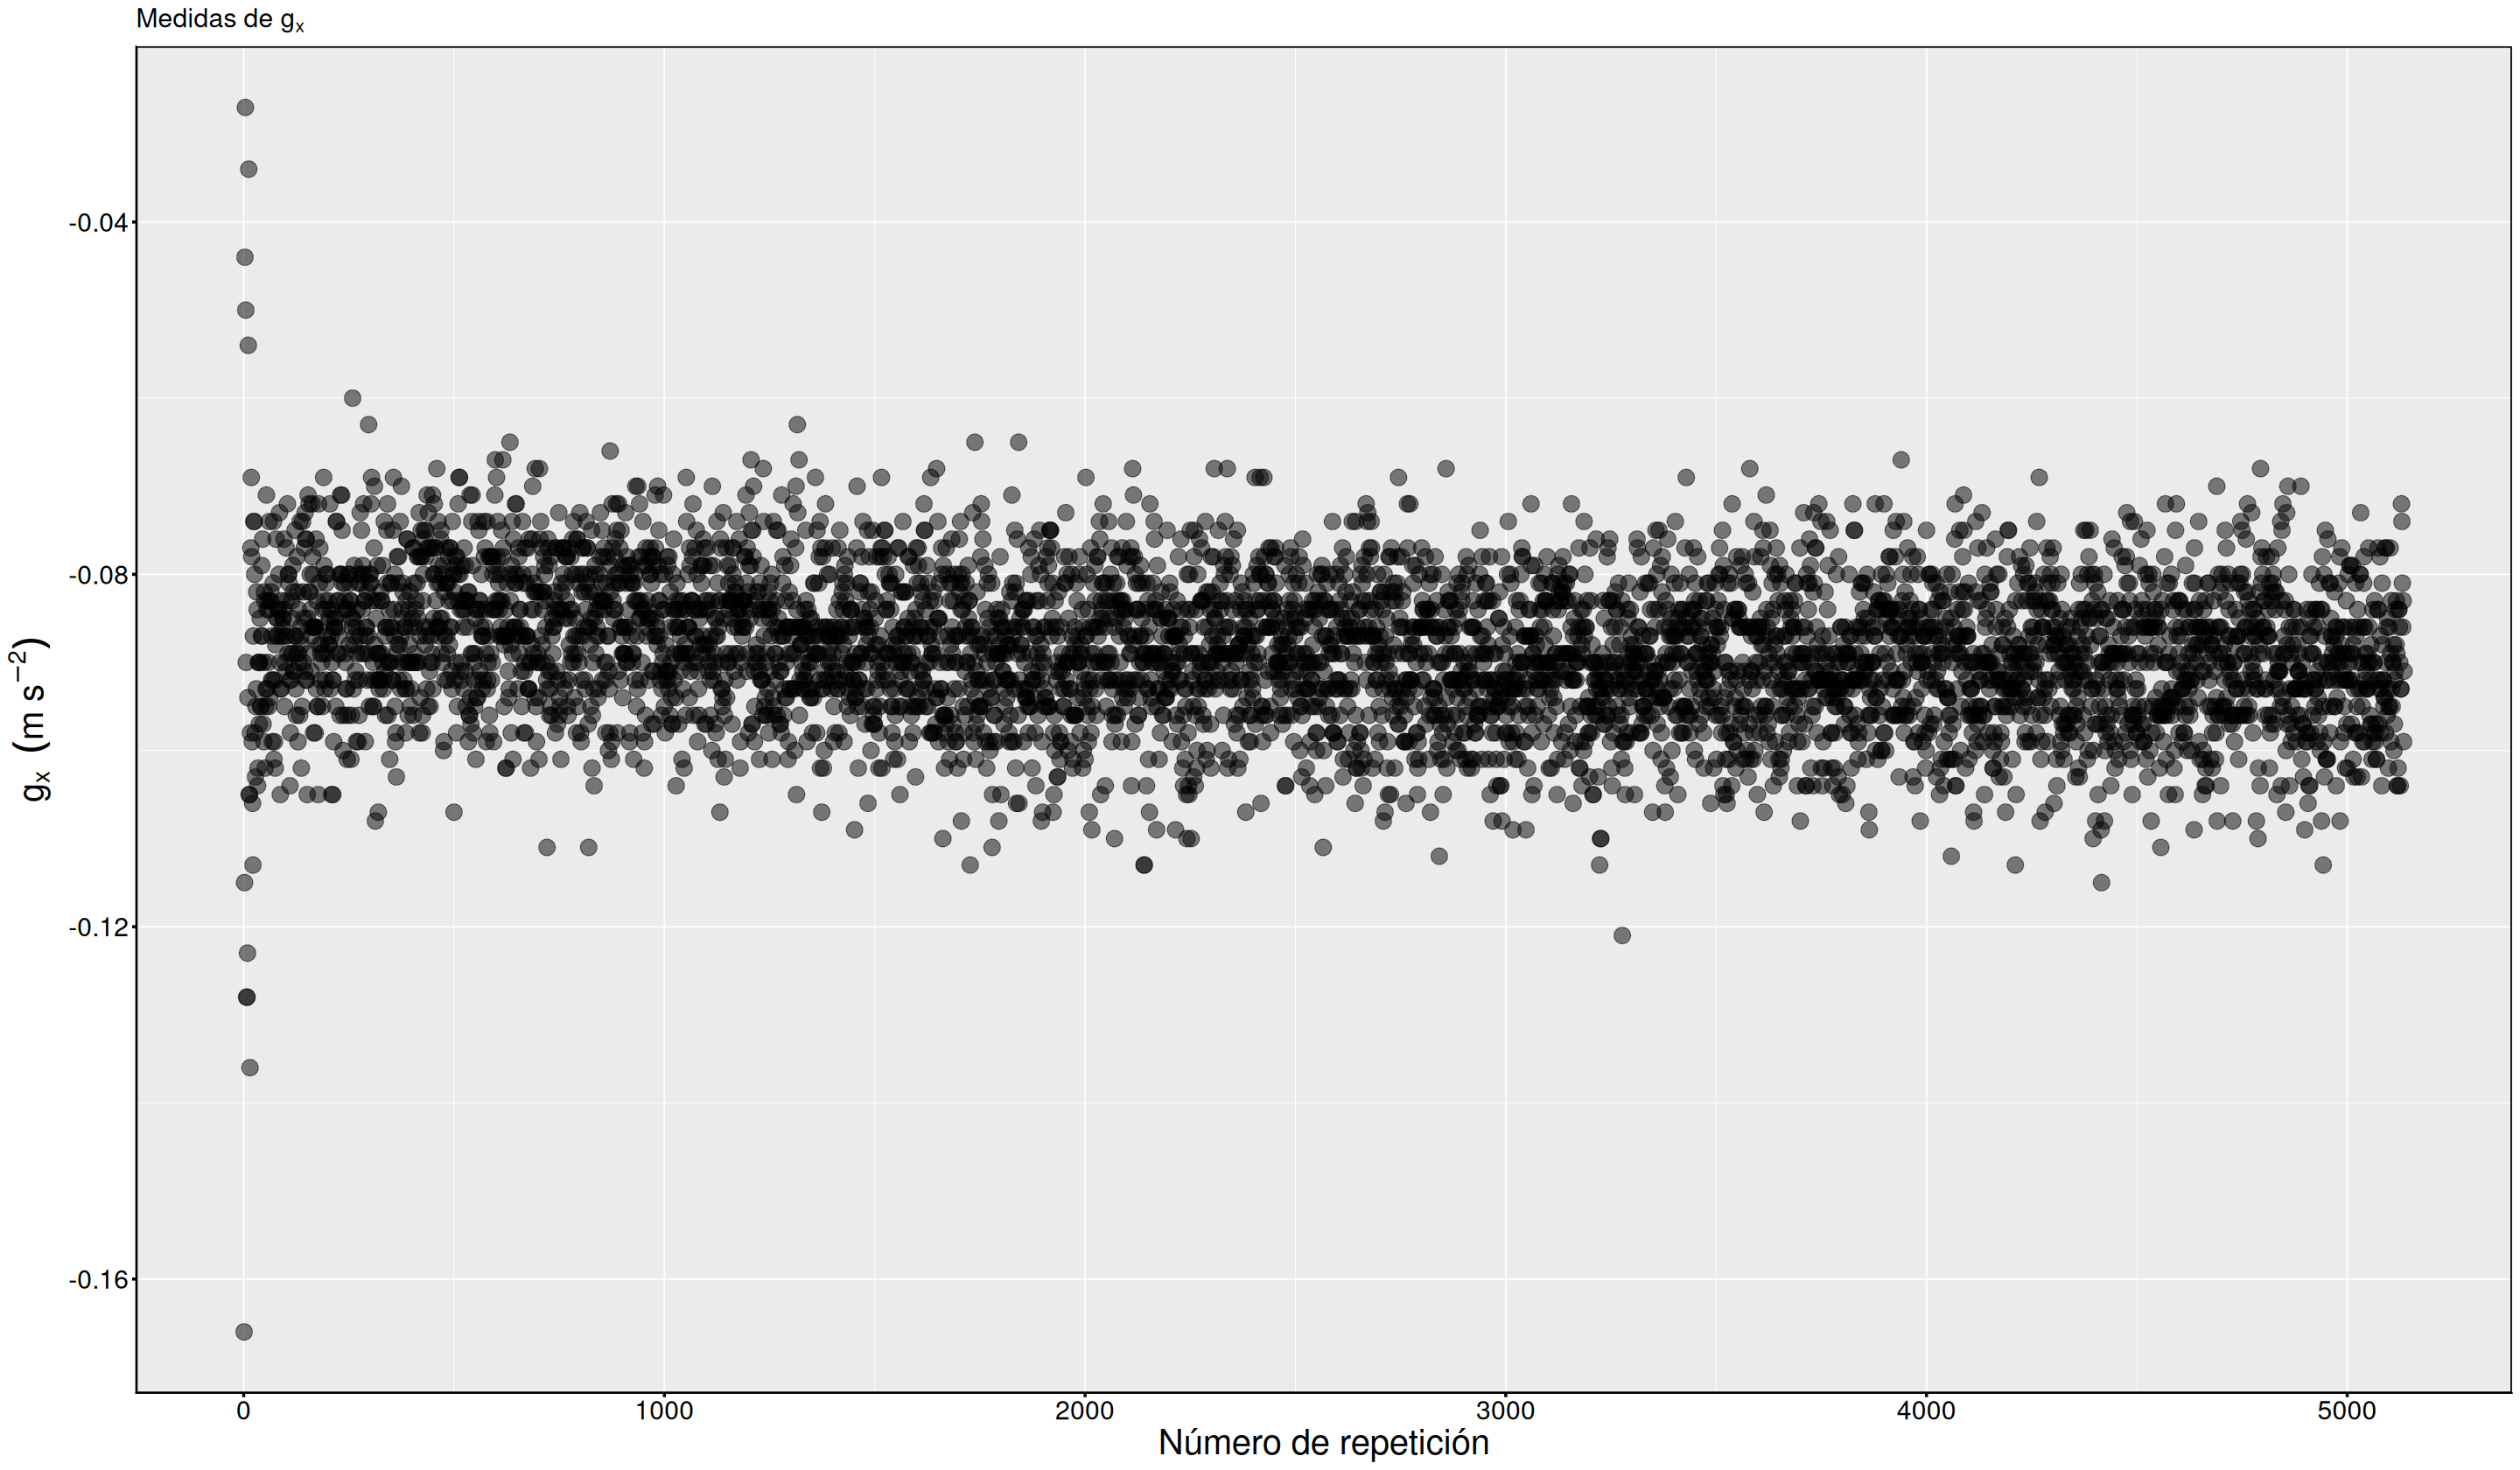

In [26]:
#gráfico gx
graf_gh <- ggplot(data = gh) + 
geom_point(aes(x = N, y = x), size = 5, alpha = 0.5) + 
ggtitle(TeX("Medidas de $g_x$")) +
ylab(TeX("$g_x \\; (m \\, s^{-2})$")) +
xlab("Número de repetición") + 
temajuan
fig(24,14);show(graf_gh)

Vemos que:
* La medida parece *estable* (no crece ni decrece), lo que es lo más importante.

* Al principio hay un ***sacudón*** de las aceleraciones, dado por el dedo que apretó las aceleraciones. Ese sacudón puede movernos los ángulos que queremos calcular más de la cuenta...

Vamos a ver las tres aceleraciones, $g_{x,y,z}$:

### Viendo $g_h$ en los tres ejes

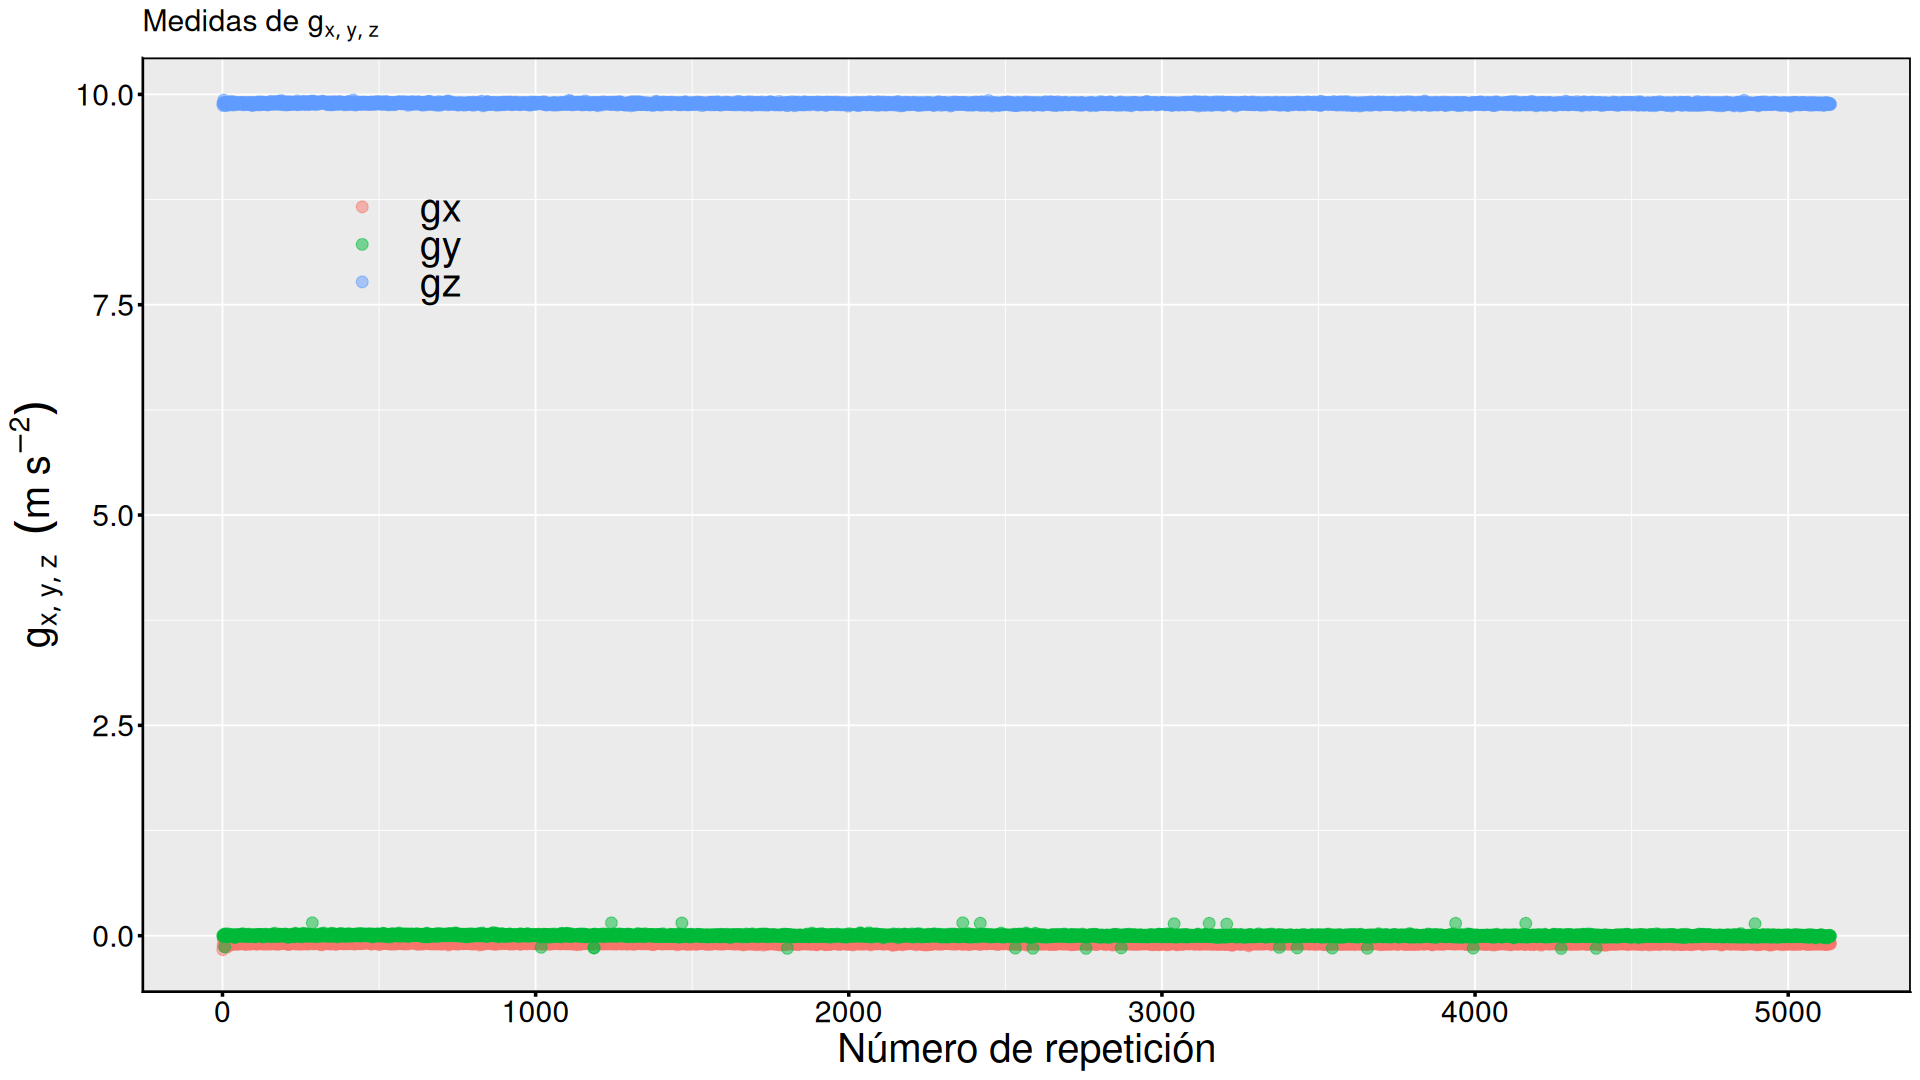

In [27]:
#graficamos todas juntas
graf_gh <- ggplot(data = gh) + 
geom_point(aes(x = N, y = x, colour = "gx"), size = 3, alpha = 0.5) + 
geom_point(aes(x = N, y = y, colour = "gy"), size = 3, alpha = 0.5) + 
geom_point(aes(x = N, y = z, colour = "gz"), size = 3, alpha = 0.5) + 
ggtitle(TeX("Medidas de $g_{x,y,z}$")) +
ylab(TeX("$g_{x,y,z}\\; (m \\, s^{-2})$")) +
xlab("Número de repetición") + 
temajuan + theme(legend.title = element_blank())
fig(16,9);show(graf_gh)

Vemos que:
* La medida de $g_z \sim 10 m\,s^{-1}$, mientras que $g_x \sim \ g_y \sim 0 m\,s^{-2}$, lo cual es congruente con el teléfono en el piso, 

* Si lo que queremos es identificar:
    1. Estabilidad (fina) de la medida
    2. Posibles valores anómalos.

Entonces la escala del gráfico en el eje vertical nos complica esta tarea, ya que es muy grande:

1. Vemos rectas *horizontalísimas* y es difícil ver cambios sutiles de pendiente.
2. No vemos las *nubes* [(nuages)](https://www.youtube.com/watch?v=qn_90PKM1xE), sino que vemos (casi) líneas.

* El problema es que no podemos identificar los valores anómalos que ya identificamos en $g_x$, ni siquiera en $g_x$

La solución a esto es graficar todos los ejes a la vez, pero ***centrándolos*** en la media (o mediana mejor) de la propia distribución, es decir:
$$
g_{x, centrado} \;\;\;= g_x - Q_{0.5}\;(g_x) \;\;  \text{ó} \;\; g_{x, centrado} \;\; = g_x - \overline{g}_x  
$$

voy a usar la primera, donde $Q_{0.5}\;(g_x)$ es la mediana de la distribución de valores.

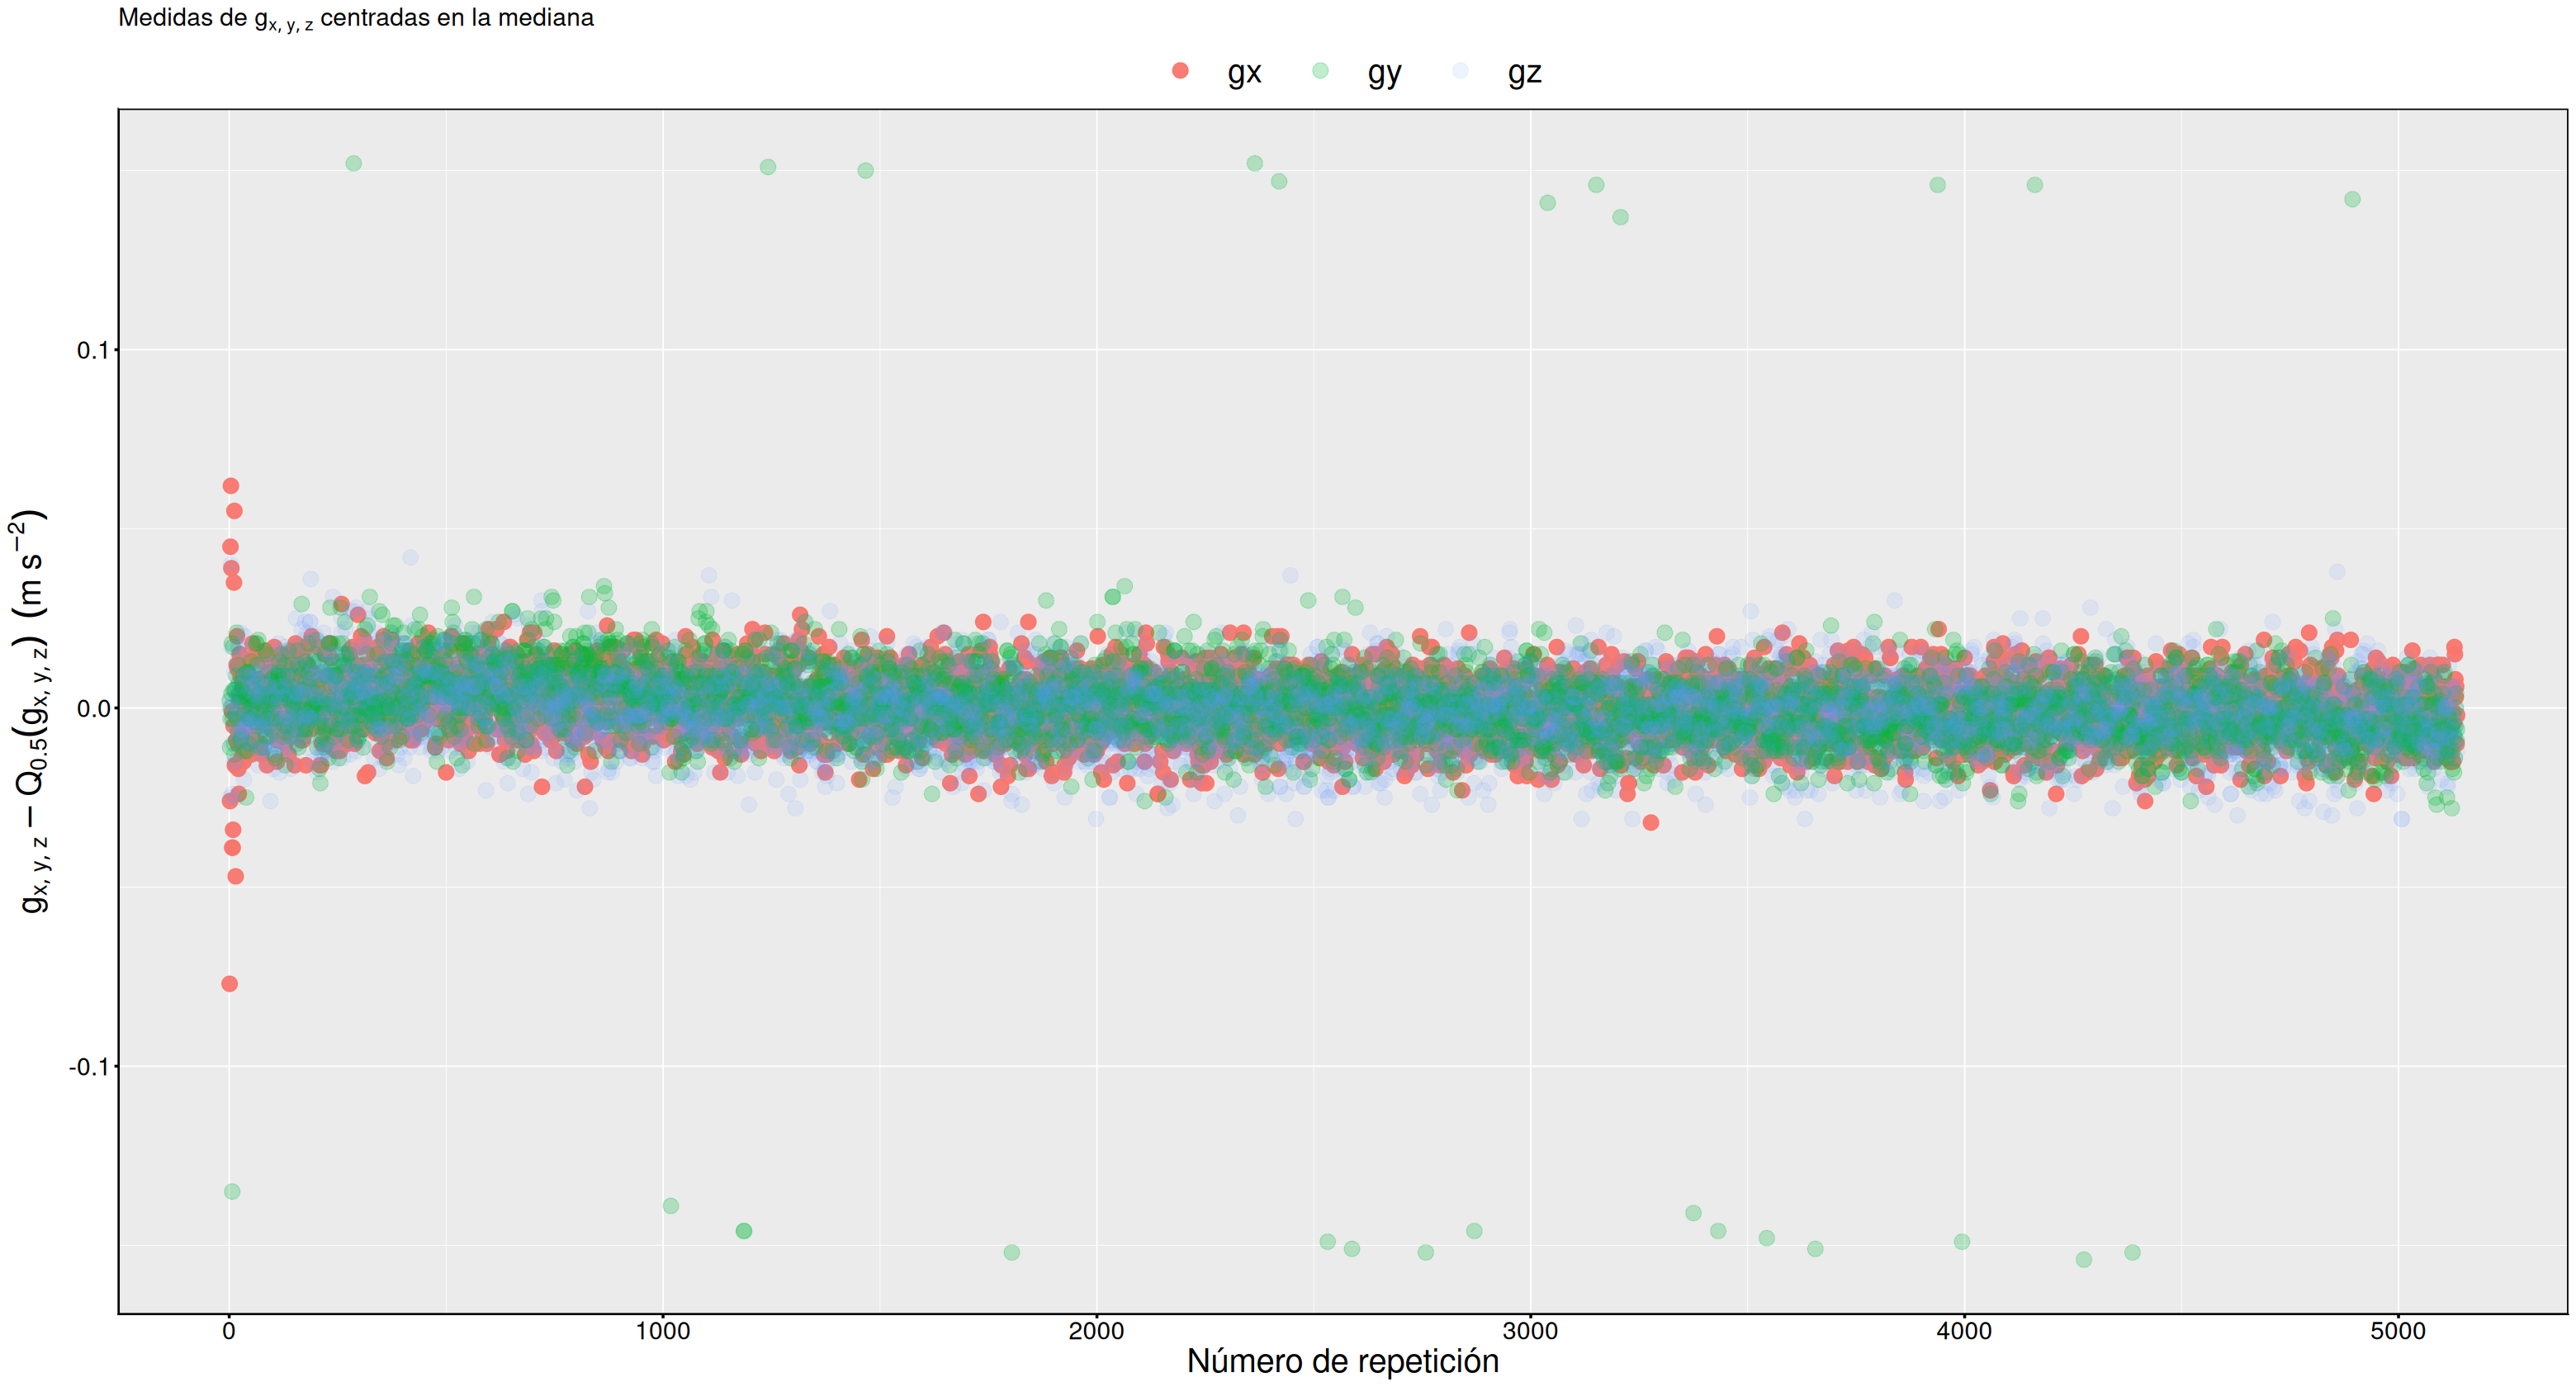

In [28]:
#graficamos centrados
graf_gh <- ggplot(data = gh) + 
geom_point(aes(x = N, y = x - median(x), colour = "gx"), size = 5, alpha = 0.95) + 
geom_point(aes(x = N, y = y - median(y), colour = "gy"), size = 5, alpha = 0.25) + 
geom_point(aes(x = N, y = z - median(z), colour = "gz"), size = 5, alpha = 0.1) + 
ggtitle(TeX("Medidas de $g_{x,y,z}$ centradas en la mediana")) +
ylab(TeX("$g_{x,y,z} - Q_{0.5}(g_{x,y,z})\\; (m \\, s^{-2})$")) +
xlab("Número de repetición") + 
temajuan + theme(legend.title = element_blank(), legend.position = "top", legend.direction = "horizontal")
fig(26,14);show(graf_gh)

Vemos que:

* Ahora sí se ven los valores anómalos en todas las series, con su colorcito.

* Tanto la serie de $g_x$ (rojita) como la de $g_y$ (verdecita) tienen valores anómalos.

Los valores anómalos están al principio (apretar el botón sacude el teléfono)

Obvio que sería bueno sacarlos, pero, son 11 ángulos x 3 ejes x dos cotas (una inferior y otra superior), lo que nos dice que si usáramos el método ***brutal*** (elegir cotas), entonces tendríamos que elegir 11x3x2 = 66 cotas a mano para sacar los valores. No lo recomendamos.

Una forma es sacar los datos anómalos del cálculo de ángulos con el acelerómetro:
* No hay que ver 66 cotas, sino sólo 22.
* Con un poco de suerte (y uso de recursos de la teoría) hacemos algo un poco más automático.

# Cuentas de los modelos

## 1. Ángulos a partir de CO y CA

En mi caso (el de uds puede ser un poco diferente si simplificaron las medidas), tenemos CO y CA en una tabla:

In [29]:
#tabla CO y CA
head(reg, n = 3);

,Medida,CO,CA
,<int>,<dbl>,<dbl>
1,1,19.2,100.0
2,2,25.0,98.8
3,3,29.9,97.3


Podemos calcular un ángulo, usando el arco tangente:

$$
\theta_i = arctan\Big(\frac{CO}{CA} \Big)
$$

y su error como:

$$
\delta \theta = \dfrac{1}{1+(CO/CA)^2} \dfrac{1}{CA} \delta CO + \dfrac{1}{1+(CO/CA)^2}\dfrac{CO}{CA^2}  \delta CA
$$


In [30]:
#calculamos ángulos e incertezas. dCO y dCA son 0.1 cm = 1 mm
reg$theta <- atan(reg$CO/reg$CA)*180/pi; #sale en sexagesimales
reg$dtheta <- (1 / (1 + (reg$CO / reg$CA)^2 ) ) * ( ( 1 / reg$CA) * 0.1 + (reg$CO/reg$CA) * 0.1) * 180/pi
head(reg, 14)

,Medida,CO,CA,theta,dtheta
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,19.2,100.0,10.86853,1.116226
2,2,25.0,98.8,14.19987,1.417053
3,3,29.9,97.3,17.08204,1.662569
4,4,35.1,95.6,20.16095,1.906565
5,5,39.3,94.0,22.68908,2.090921
6,6,44.5,91.7,25.88628,2.301038
7,7,50.0,88.8,29.38225,2.498509
8,8,55.2,85.7,32.78588,2.655585
9,9,60.0,82.4,36.06043,2.771878


## 2. Ángulos Acelerómetro

Esto va a sonar cuentoso...pero tranca que es un producto punto. La idea es:

1. Calcular el producto punto entre $g_h$ y cada uno de los $g_\theta$
2. Dividirlos por el producto de sus módulos
3. Calcular el arco coseno para obtener el ángulo.
4. Darle una mirada al valor del ángulo estimado con los catetos.
#### Primero lo probamos (a ver si funciona) para un ángulo:

In [31]:
#producto punto para un ángulo
g1 = gt[gt$Medida == 1, ]; #sacamos la primera medida (el ángulo ~  10° arriba)

#angulo en tres pasos: 
g1$ang <- gh$x * g1$x + gh$y * g1$y + gh$z * g1$z; #1.producto punto

#2.divido el producto punto por el producto de los módulos
g1$ang <- g1$ang / ( ( gh$x^2 + gh$y^2 + gh$z^2)^(1/2) * ( g1$x^2 + g1$y^2 + g1$z^2 )^(1/2))

g1$ang <- acos(g1$ang) * 180 / pi; #3.arco coseno y sale en grados sexagesimales

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


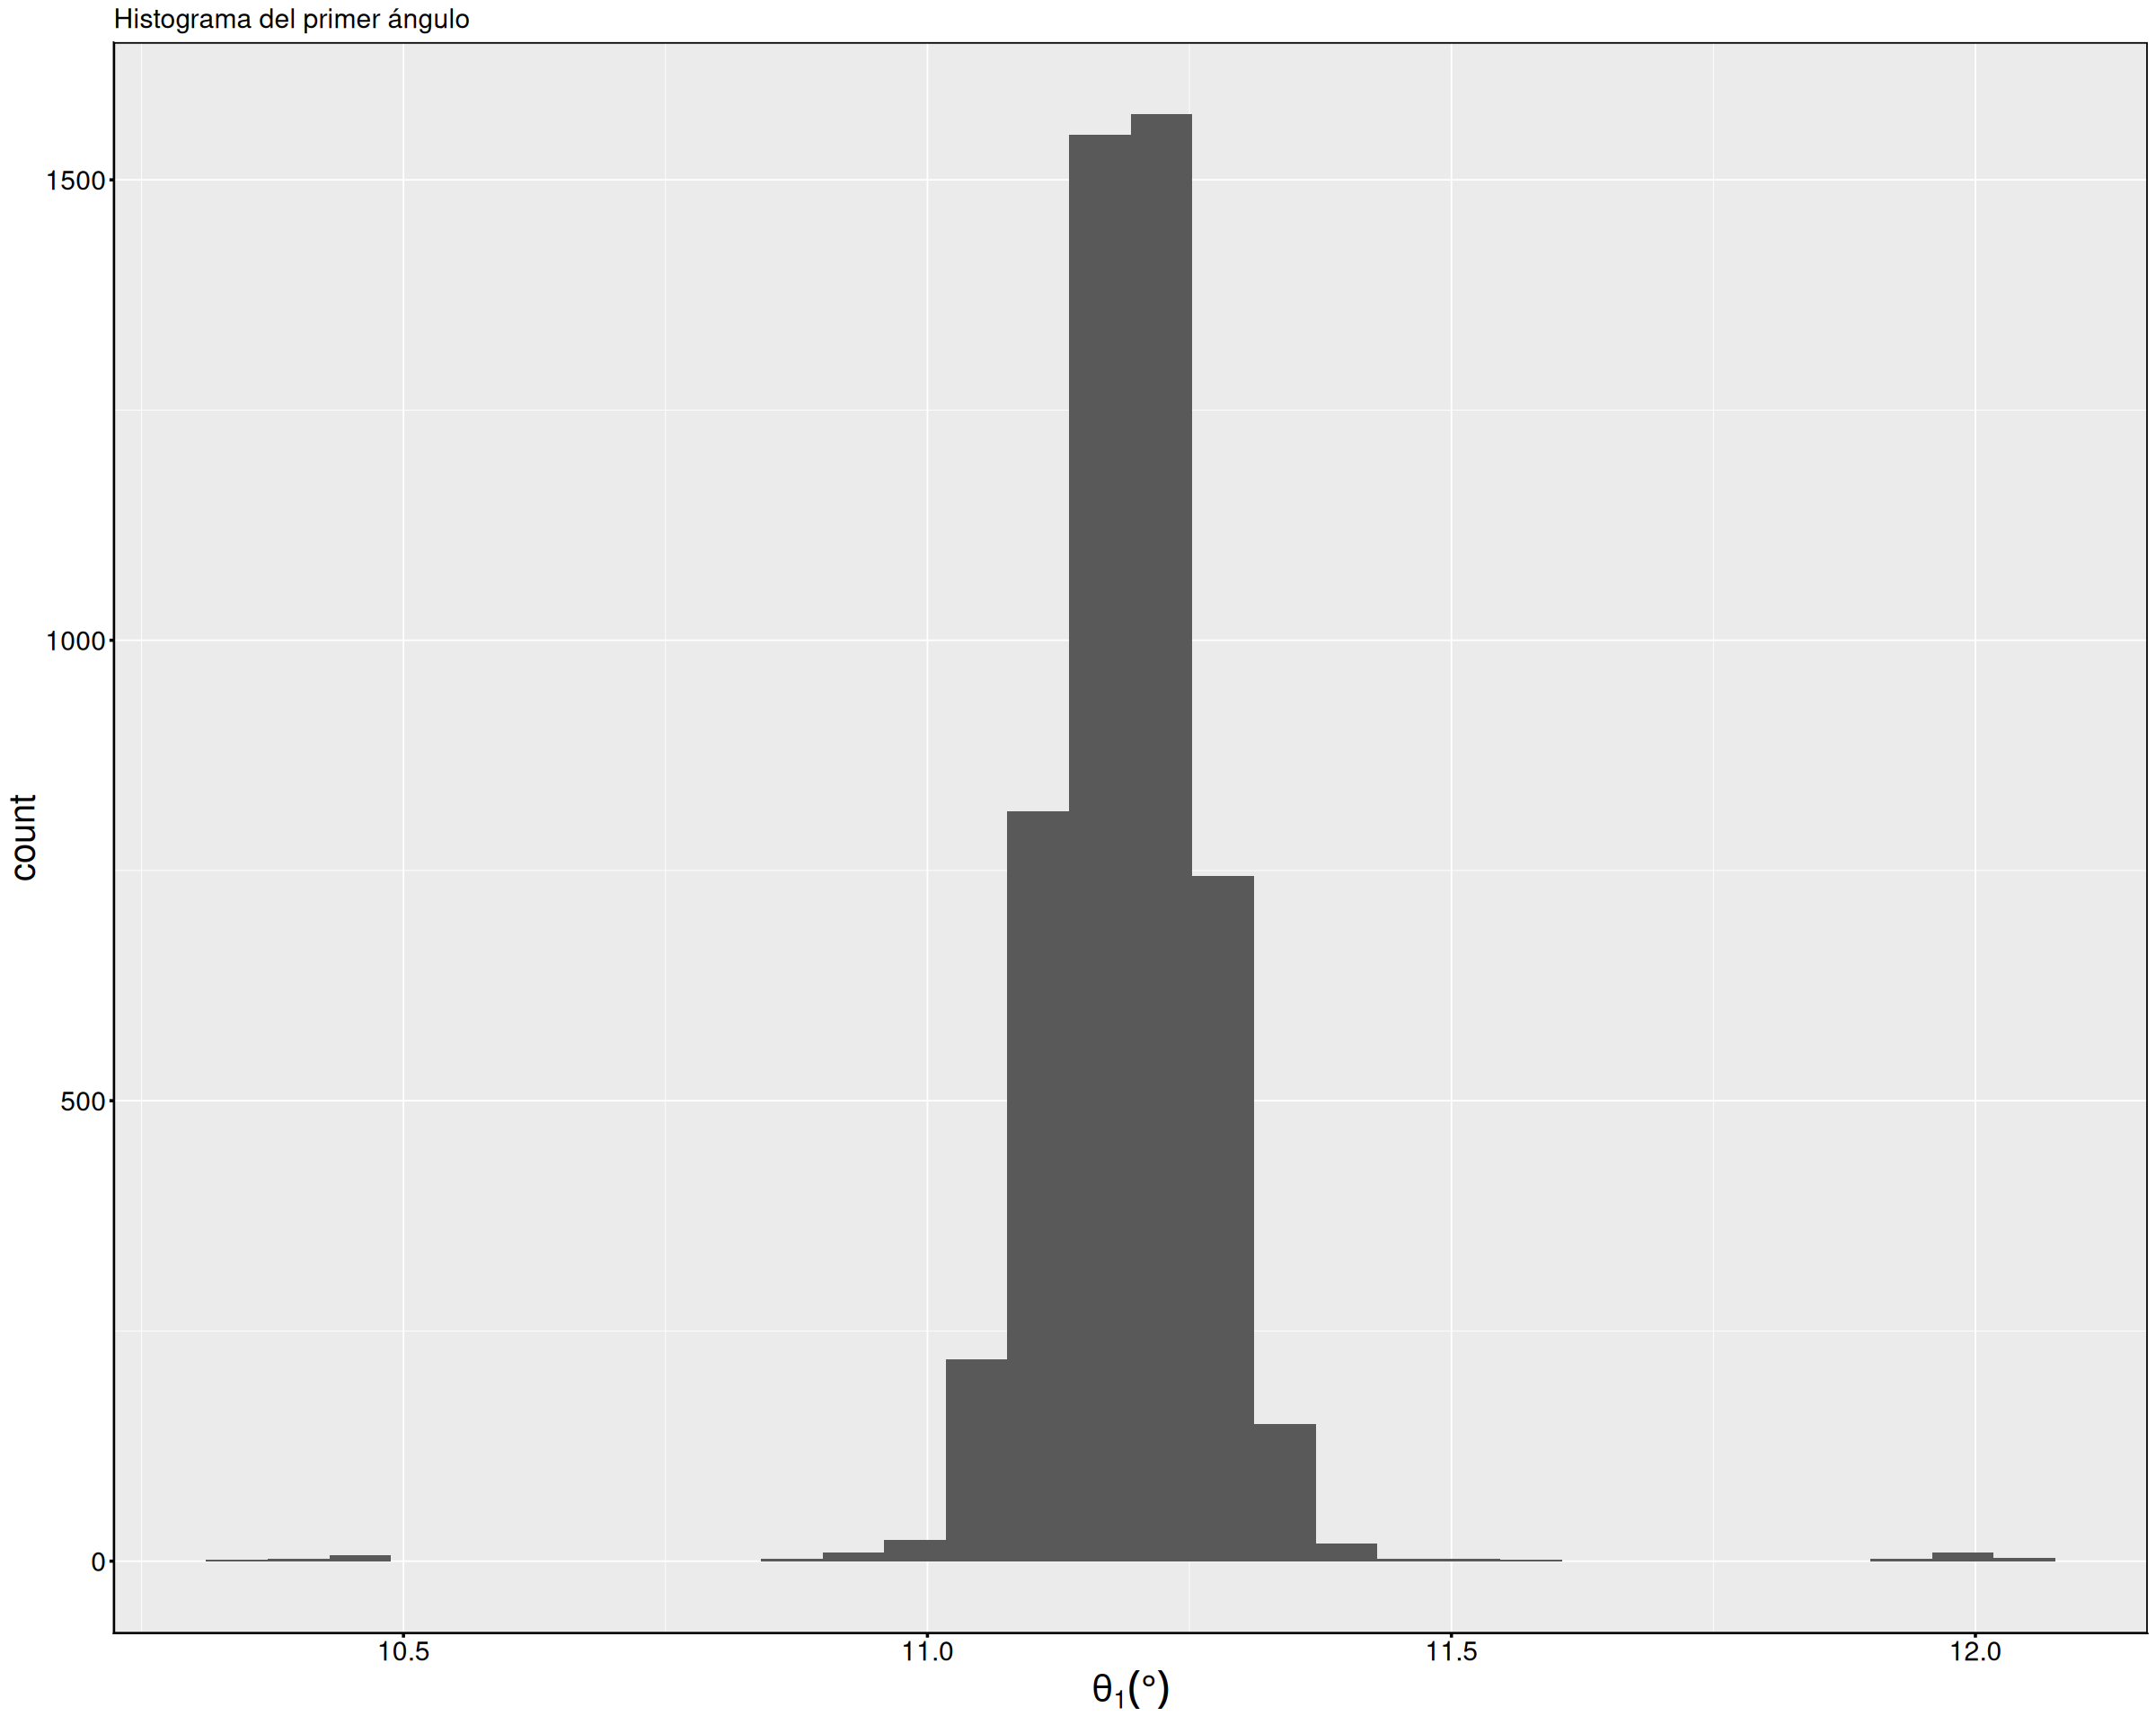

In [50]:
#histograma de ángulos
hang <- ggplot(data = g1) + 
geom_histogram(aes(x = ang)) + 
ggtitle("Histograma del primer ángulo") + xlab(TeX("$\\theta_1 (\\degree)$")) + 
temajuan
fig(20,16)
show(hang)

 Vemos que:
 * La media está cerca de $\bar{\theta_1} \sim 11.2°$, muy cerca de los que calculamos con la trigonometría.
 * Hay valores anómalos.
 * Sesgarán nuestros estimadores, incluso los ajustes.

     
#### Ahora para todos los ángulos

1. Hacemos la cuenta del arco coseno para todas las medidas que tenemos.
1. Agregamos columnas para los ángulos estimados mediante las medidas de los catetos.!
1. Hacemos una gráfica de $\theta_{acel} \; vs. \theta_{catetos}$.
   1. Agregamos la recta $\theta_{acel} = \theta_{cetetos}\;\;$ (la calibración perfecta (por inexistente) del inclinómetro).
   1. Agregamos un ajuste lineal.

In [52]:
#ángulos acel/agregamos ángulos CA/CO
ang_acel  <- vector(mode = "numeric")

for(i in 1:max(gt$Medida)){
g1 <- gt[gt$Medida == i, ]

ang1 <- gh$x * g1$x + gh$y * g1$y + gh$z * g1$z; #1.producto punto
#2.divido el producto punto por el producto de los módulos
ang1 <- ang1 / ( ( gh$x^2 + gh$y^2 + gh$z^2)^(1/2) * ( g1$x^2 + g1$y^2 + g1$z^2 )^(1/2))
ang1 <- acos(ang1) * 180 / pi; #3.arco coseno y sale en grados sexagesimales    

ang_acel    <- c(ang_acel,ang1)
   
}
gt$ang_acel <- ang_acel
gt$ang_cat  <- rep(reg$theta, each = nrow(gh))
gt$dang_cat  <- rep(reg$dtheta, each = nrow(gh))
head(gt,10)

,N,x,y,z,Medida,ang_acel,ang_cat,dang_cat
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,1,0.622,1.788,9.662,1,11.42129,10.86853,1.116226
2,2,0.609,1.789,9.685,1,11.32785,10.86853,1.116226
3,3,0.601,1.790,9.728,1,11.07909,10.86853,1.116226
4,4,0.608,1.780,9.676,1,11.04674,10.86853,1.116226
5,5,0.623,1.797,9.672,1,11.19577,10.86853,1.116226
6,6,0.610,1.780,9.725,1,11.02796,10.86853,1.116226
7,7,0.599,1.796,9.682,1,12.04595,10.86853,1.116226
8,8,0.605,1.774,9.646,1,11.26779,10.86853,1.116226
9,9,0.604,1.789,9.708,1,11.15795,10.86853,1.116226


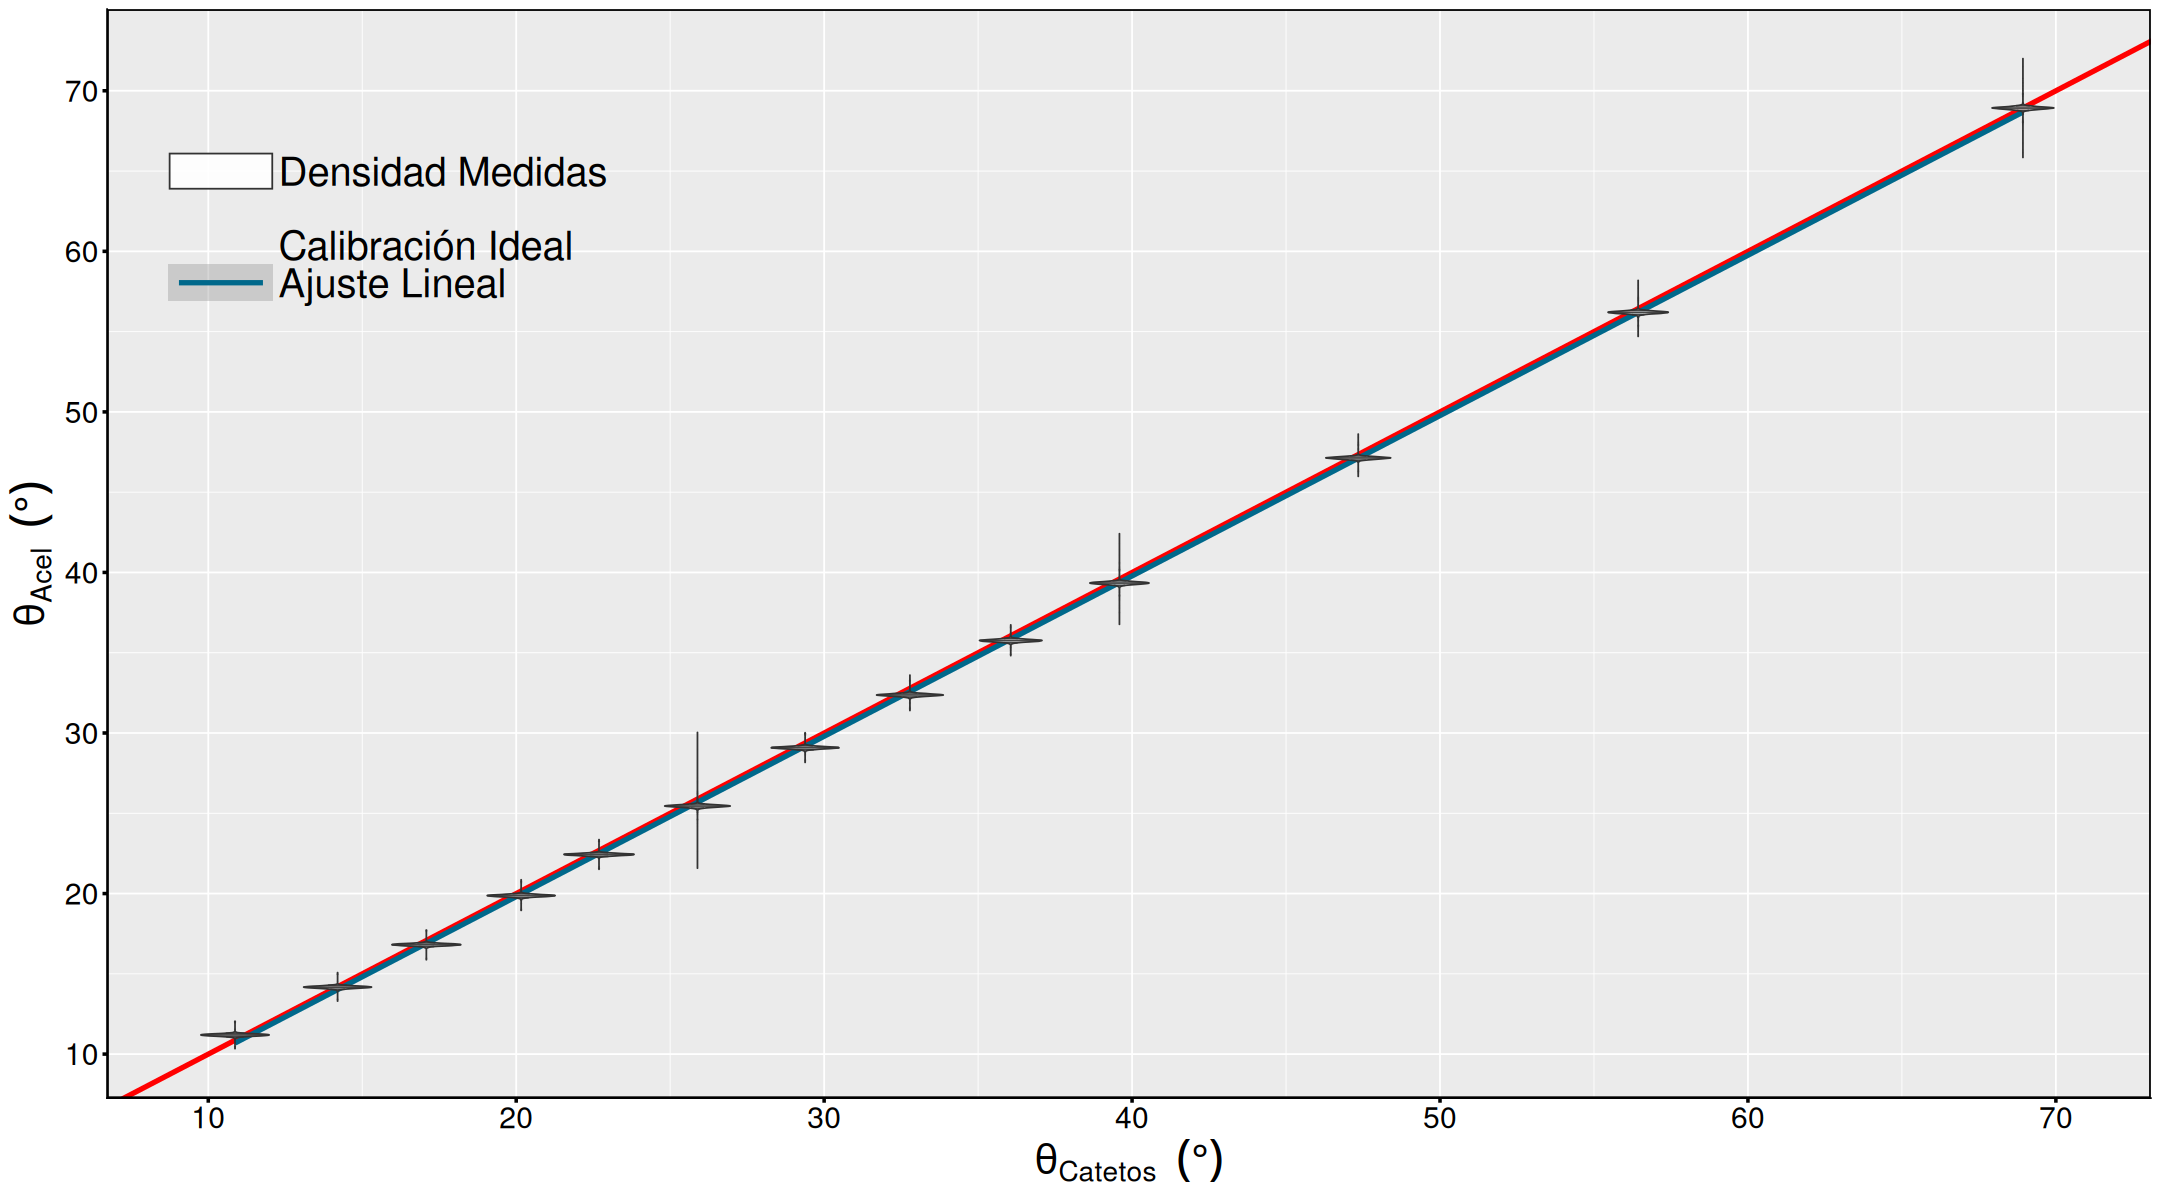

In [55]:
#graficamos y vemos calibración
gangulos <- ggplot() + 
geom_abline(aes(intercept = 0, slope = 1, colour = "Calibración Ideal"), lwd = 1.5,show.legend = F) +
geom_smooth(data = gt, aes(x = ang_cat, ang_acel, colour = "Ajuste Lineal"), lwd = 1.5,method = "lm", formula = "y ~ x", fullrange = T) + 

geom_violin(data = gt, aes(x = ang_cat, y = ang_acel, group = as.factor(ang_cat),
                           fill = "Densidad Medidas"),
            draw_quantiles = c(0.05,0.5, 0.95),
            alpha = 0.9,
            scale = "count") +

#geom_point(data = gt, aes(x = ang_cat, y = ang_acel)) +  #descomentar para puntos
scale_fill_manual(breaks = "Densidad Medidas", values = "White") + 
scale_colour_manual(breaks = c("Calibración Ideal", "Ajuste Lineal"), values = c("Red","DeepSkyBlue4") ) + 
scale_x_continuous(breaks = seq(0,90,10), labels = seq(0,90,10)) + 
scale_y_continuous(breaks = seq(0,90,10), labels = seq(0,90,10)) + 
xlab(TeX("$\\theta_{Catetos}\\; (\\degree)$")) + ylab(TeX("$\\theta_{Acel}\\; (\\degree)$")) + 
temajuan + theme(legend.direction = "vertical", legend.box = "vertical", legend.title = element_blank())
fig(18,10)
show(gangulos)


Vemos que:
* Las densidades están muy centradas (la dispersión de la nube central es tan chica que no se ve otra cosa que cruces:
    * Las líneas horizontales marcan que toda la densidad está en el centro.
    * las líneas verticales indican que hay valores anómalos para casi todas las medidas.

* Si vemos la recta $\theta_{acel} = \theta_{catetos}$, las densidades están *tan cerca* que parece imposible que el método funcione tan bien.

* Si vemos el ajuste, parece casi copiar la calibración ideal.

In [56]:
#valores del ajuste lineal
ab <- lm(gt$ang_acel ~ gt$ang_cat); rab <- summary.lm(ab);
rab$coefficients
cat("R^2 = ", rab$r.squared)

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-0.1631715,1.932846e-03,-84.42034,0
gt$ang_cat,0.9986717,5.315867e-05,18786.61905,0


R^2 =  0.9998109

La recta que une puntos es:

$$
\theta_{acel} = -0.163\; + 0.9987 \;\theta_{catetos}
$$

* Casi 0 la ordenada al origen (la calibración ideal).

* Casi 1 la pendiente (la calibración ideal).

Esto puede mejorarse si limpiamos los datos de los ángulos:

* Ya sabemos que tienen valores anómalos que:
    
    * Ensanchan las distribuciones.
    
    * Sesgan nuestros parámetros.
    
    * Impiden el ***trastorno obsesivo-compulsivo***, conseguir una recta ***perfecta*** (que igual no vamos a conseguir).
    
    ***
    ***



# Limpieza de los datos

Si bien podríamos haber hecho una limpieza de los datos de aceleración, esperamos hasta tener los resultados de los ángulos estimados mediante el acelerómetro para esto.

¿Funciona siempre? No, a veces es mejor limpiar los datos de entrada, pero sólo por ***pereza*** limpio la salida.

* Si los ángulos dieran dispersiones tremendas (que no la dan), buscaría en las relaciones entre la entrada de datos y la salida.

* Si esta idea (que ya está implementada) tuviera que funcionar en tiempo real, entonces sería mejor limpiar las aceleraciones en tiempo real...

## 2. Señal de ángulos limpia

Limpiar los datos siempre es importante, porque los estimadores que usamos como la media y la desviación estándar se sesgan mucho con los datos anómalos.

Los métodos que usamos para **limpiar valores anómalos en la medida del periodo**, fueron:

1. **Fuerza bruta: poner cotas para limpiar valores alejados de la "nube" de puntos**, o de la parte central del histograma.

2. **Usar información previa (los tiempos de reacción al estímulo visual de una persona), y la 
mediana** en lugar de la media, para elegir como pivote de las cotas. Este método puede ser algorítmico, lo cual es valioso. 

**Este caso es distinto**:
1. Sería engorroso (y a veces imposible) ver todos los histogramas de los ángulos.
1. No tenemos información previa que nos sirva para establecer cotas de antemano.

#### Problema básico de los valores anómalos

Los datos anómalos son **ruido indeseable** que afecta nuestro **ruido esperable** (estas no son denominaciones *formales*, pero se entienden).

En un histograma se verían como:

In [57]:
#anómalos generados
muestra = 4000; nanomalos = 200
xlimpios <- rnorm(mean = 10, sd = 1, n = muestra)
xanomalos <- c(runif(min = 0.5, max = 2, n = nanomalos/2), runif(min = 27, max = 36, n = nanomalos/2))
x <- c(xlimpios, xanomalos)
Tipo <- c(rep("Datos Limpios", times = muestra), rep("Valores Anómalos", times = nanomalos));
d <- data.frame(x, Tipo)
n <- sample(1:length(x), replace = F, size = length(x))
d <- d[n, ];
cat("Son ", muestra, " datos en la nube central y ", nanomalos, " datos anómalos \n")

Son  4000  datos en la nube central y  200  datos anómalos 


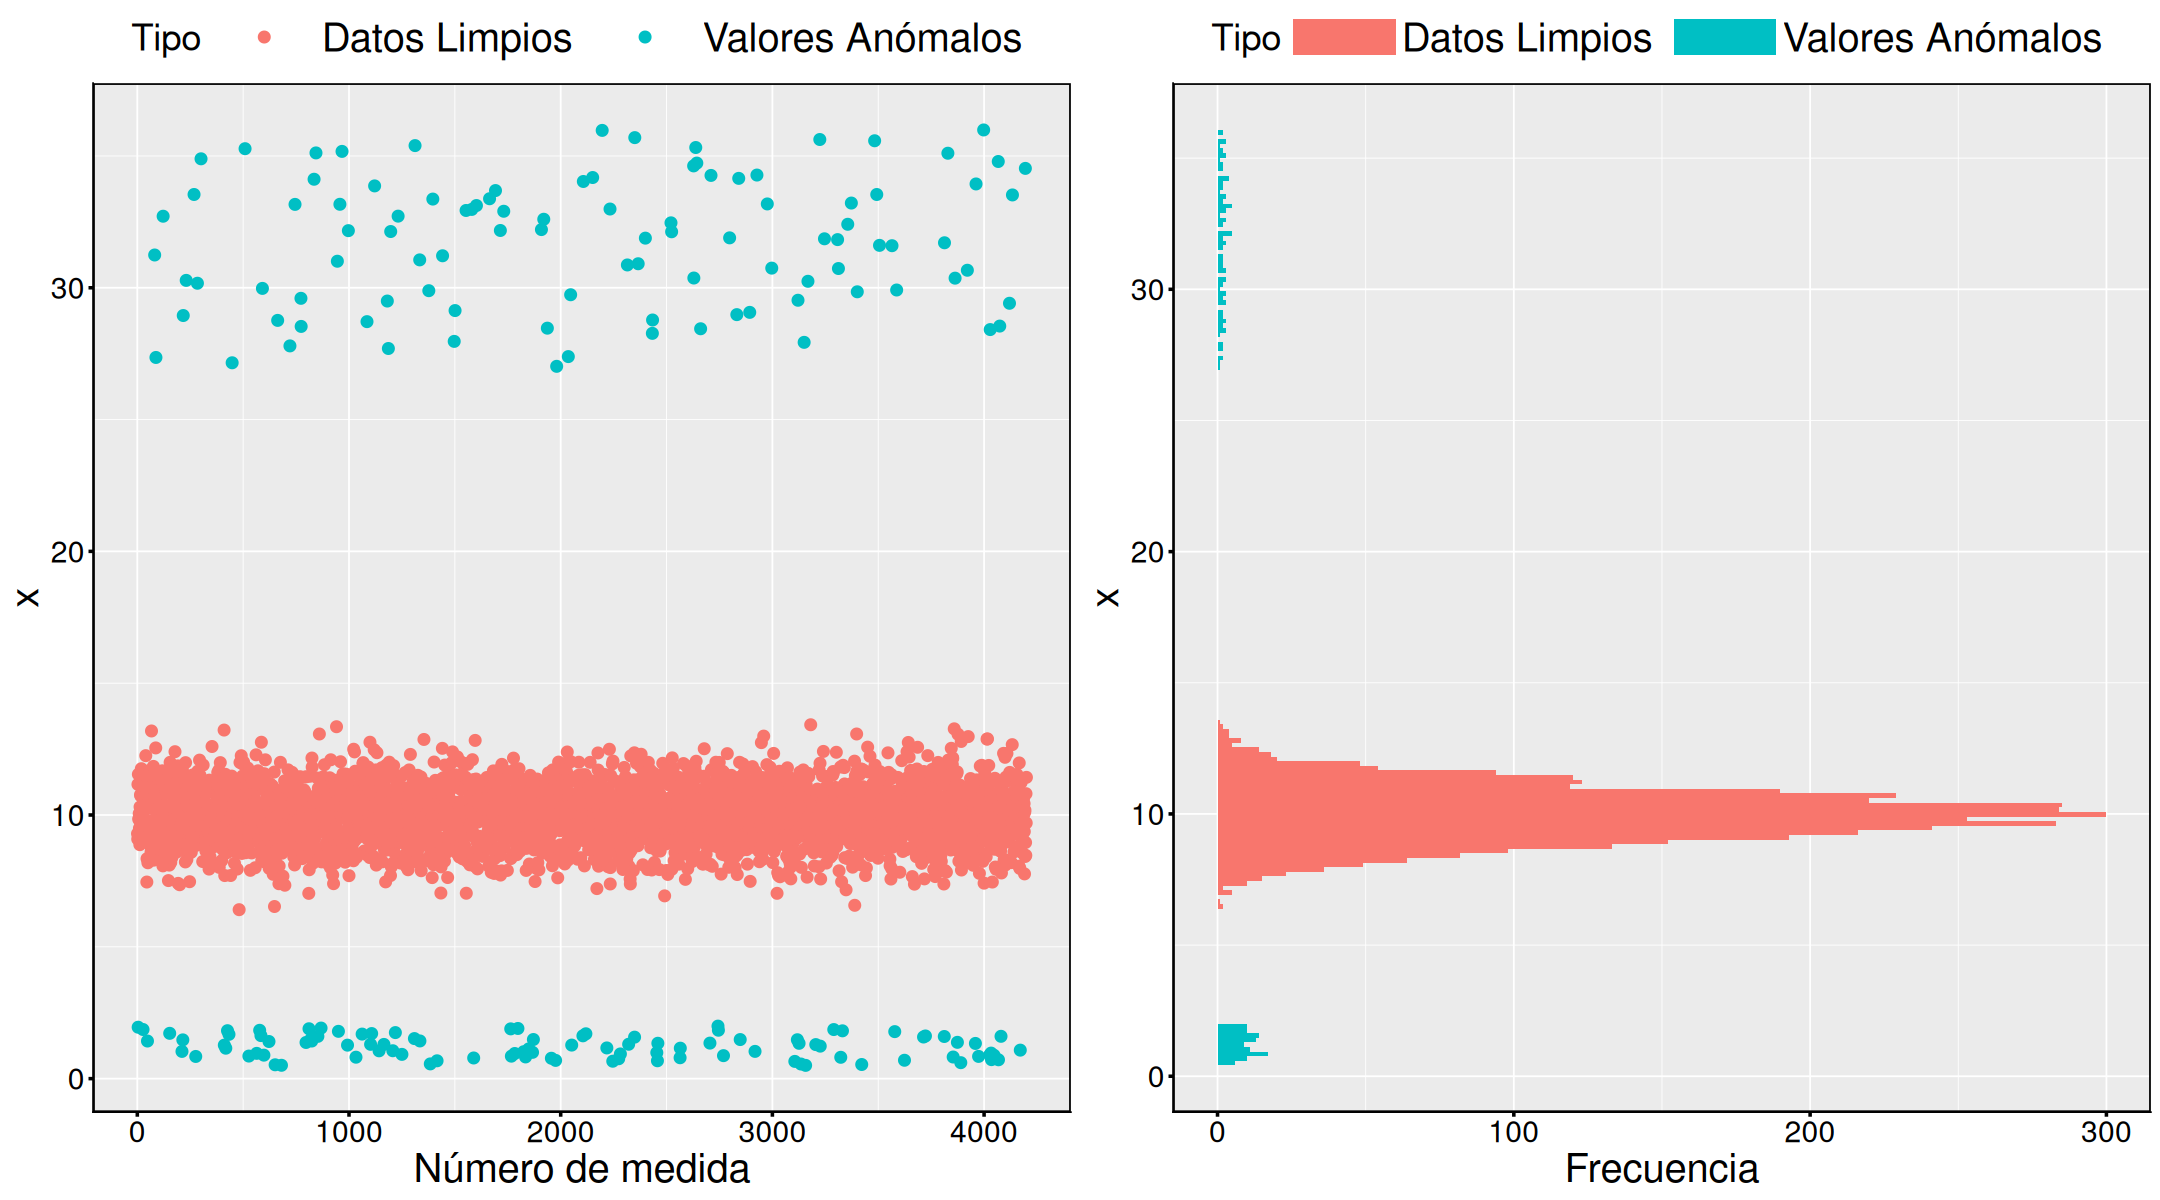

In [58]:
#Gráfico e histograma con anomalos:
ga <- ggplot(data = d) + 
geom_point(aes(y = x, x = 1:length(x), colour = Tipo), size = 3) + 
xlab("Número de medida") +
temajuan + theme(legend.position = "top", legend.direction = "horizontal") 

ha <- ggplot(data = d) + 
geom_histogram(aes(x = x, fill = Tipo), bins = nclass.FD(d$x)) + 
ylab("Frecuencia") + 
coord_flip()  +
temajuan + theme(legend.position = "top", legend.direction = "horizontal")
 
gridExtra::grid.arrange(ga,ha, ncol = 2)

### Cuantiles *for dummies*
Los cuantiles, formalmente, tienen que ver con probabilidad. Sin embargo, vamos a dar un *rodeo*, aunque habrá que interpretar un poco después.

Con una lista de números, pensar los cuantiles es bastante simple:

Si se tiene una colección de $x_i = x_1,x_2,...,x_{100}$ (n = 100 números). El cuantil $Q_{P = 10/100 = 0.1}\;\;\;\;(x)$ *puede ser pensado* de manera simple:

1. Ordenamos de menor a mayor la lista de los $x_i$
2. Vamos hasta la posición $i$.
3. El cuantil $i/100$ es $x_i$.

Ejemplo: ¿cual es la mediana?

In [59]:
#tabla cuantiles
x <- c(10,999,100,1,105,97,99,103,104);
n <- 1:length(x)
aver <- quantile(x, probs = seq(0.1,0.9,0.1), type = 2)
data.frame(n, x, x_ordenado = sort(x), Probabilidad = names(aver), cuantil_prob = unname(aver))


n,x,x_ordenado,Probabilidad,cuantil_prob
<int>,<dbl>,<dbl>,<chr>,<dbl>
1,10,1,10%,1
2,999,10,20%,10
3,100,97,30%,97
4,1,99,40%,99
5,105,100,50%,100
6,97,103,60%,103
7,99,104,70%,104
8,103,105,80%,105
9,104,999,90%,999


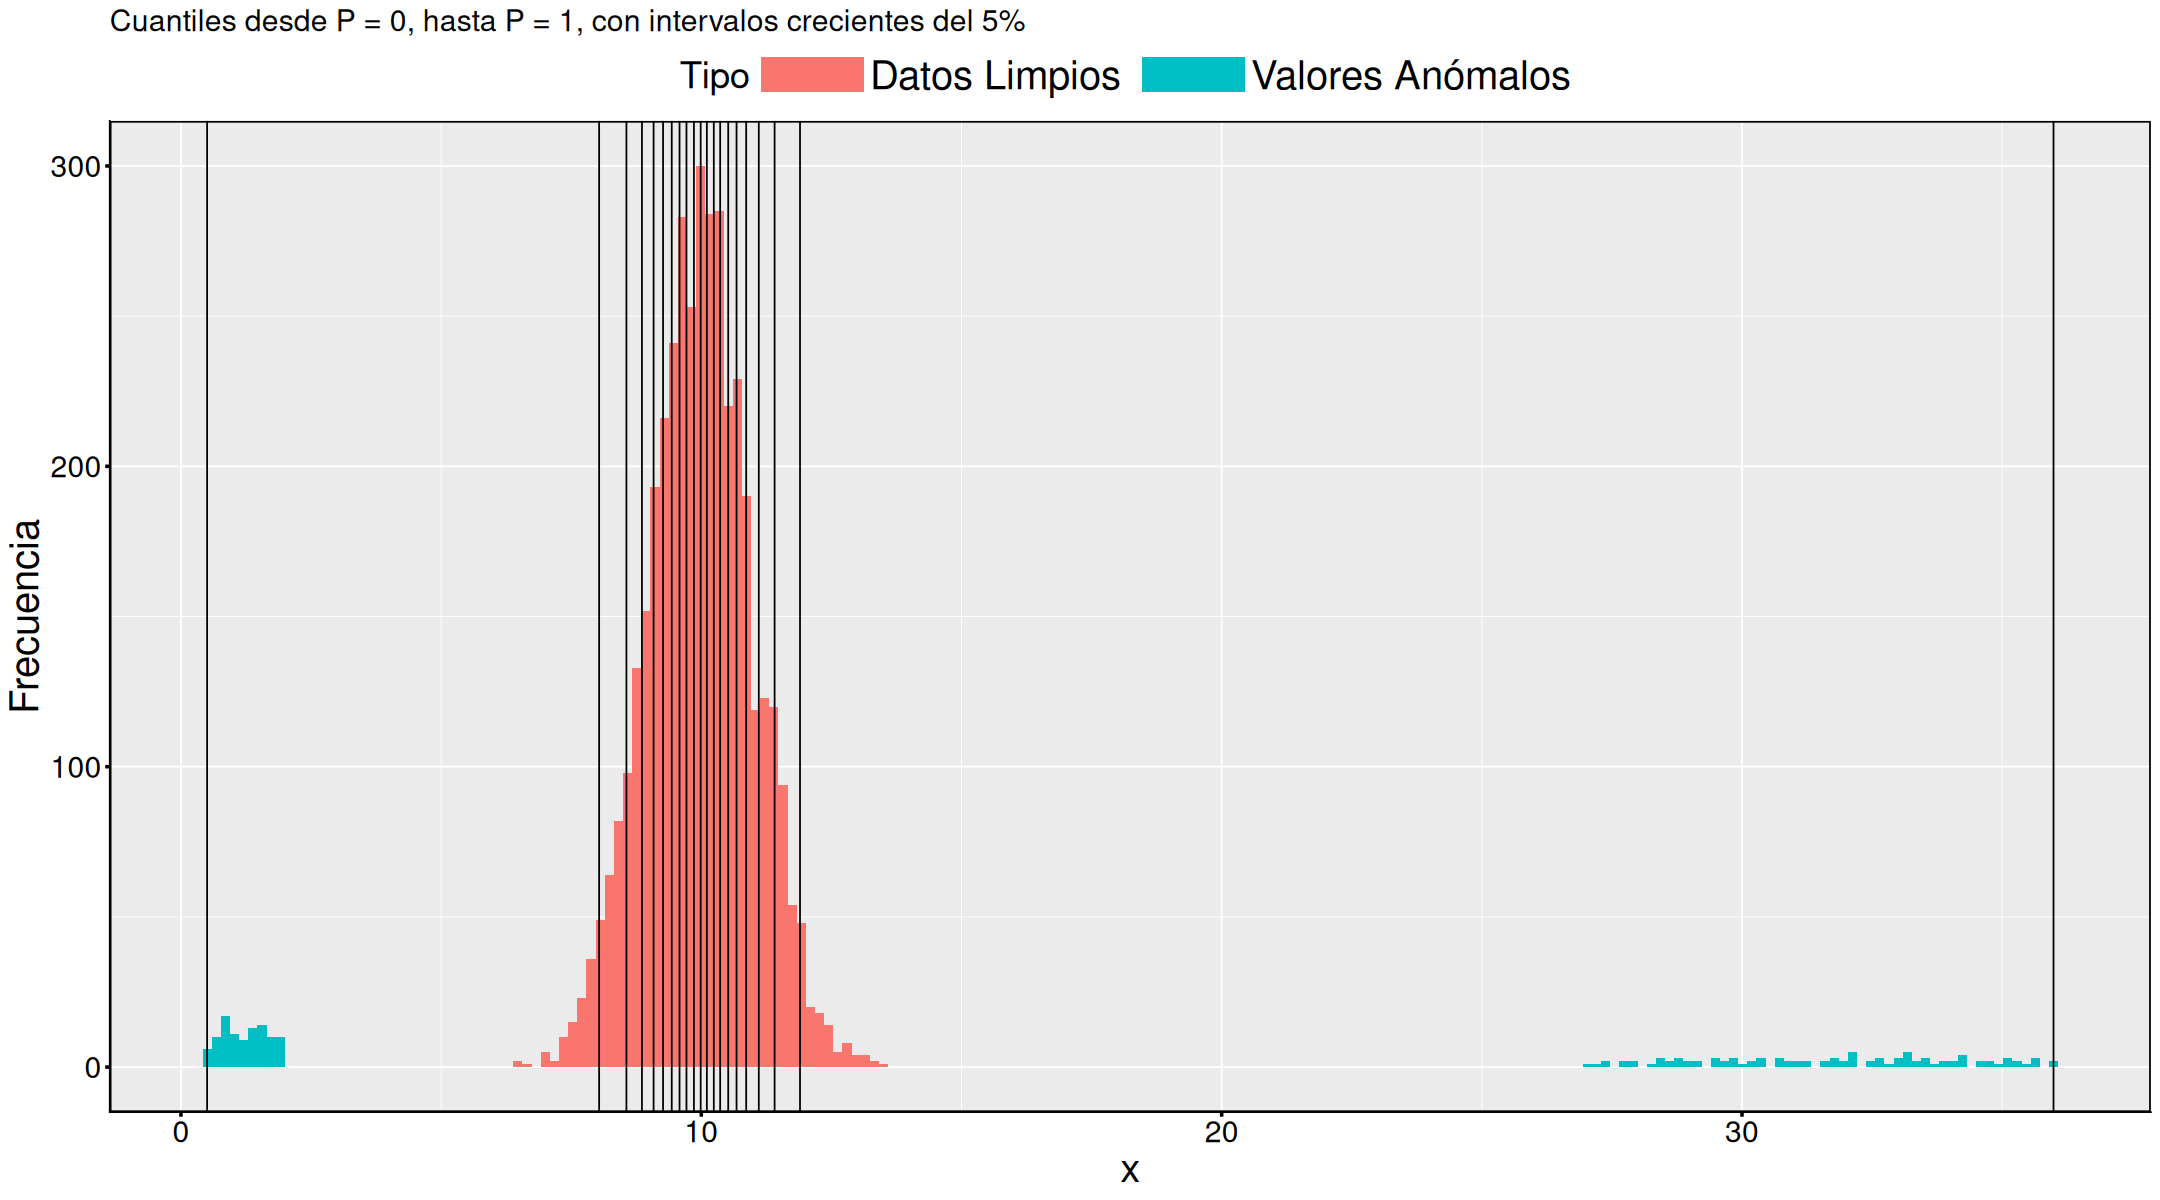

In [60]:
#histograma
ha <- ggplot() + 
geom_histogram(data = d, aes(x = x, fill = Tipo), bins = nclass.FD(d$x)) + 
geom_vline(aes(xintercept = quantile(d$x, probs = seq(0.0,1.0, 0.05)) ) ) + 
ylab("Frecuencia") + 
ggtitle("Cuantiles desde P = 0, hasta P = 1, con intervalos crecientes del 5%") + 
temajuan + theme(legend.position = "top", legend.direction = "horizontal")

show(ha)

Los valores anómalos se caracterizan por estar **muy afuera** del resto de la nube de puntos.

Los cuantiles, al ser lugares en la lista ordenada, pueden ser muy útiles, porque los valores anómalos son pocos: un salto de poco % puede significar un gran salto en lugares de una lista, quedando dentro de la nube.

#### Forma 1: Desviación estándar a partir de cuantiles

Intentamos conseguir la desviación estándar, pero esquivando los datos anómalos.

* La media se sesga fácil si hay datos anómalos. En cambio, la ***mediana de todos los datos***, si la distribución es simétrica, aproxima la ***media*** de datos limpios (sin tener que limpiar).

* La desviación estándar de una distribución normal, si la calculamos con **todos los datos**, explota. Sin embargo, si usamos los valores de cuantiles correspondientes a una desviación estándar, probablemente le peguemos **cerca** a la desviación estándar.

Vemos las probabilidades en intervalos de $\sigma$, la desviación estándar.

<img src="https://pbs.twimg.com/media/EARLn1JWwAAiYJG.jpg" width="800" />

* Queremos el cuantil $Q_{0.1588} = P_{\;15.88} \;\;$, que es el que está a la izquierda de la media por una desviación estándar.

* Queremos el cuantil $Q_{0.8412} = P_{\;84.12\;}$, que es el que está una desviación estándar a la derecha de la media.

Toda la idea es que los valores anómalos son **poquitos** respecto de la nube => no va a haber mucha diferencia entre la desviación estándar de los datos limpios y la aproximada por estos cuantiles.

Aproximando la desviación estándar así, vamos a sacar todos los datos que se encuentren a tres desviaciones a cada lado de la mediana, limpiando los datos a partir de su estructura interna en lugar de elegir cotas.

**Forma 2: Intervalo intercualrtil**
Esta es otra forma estándar de quitar las colas de datos anómalos. La idea es similar a la anterior, pero un pocon más robusta (mira más cerca de la mediana. Puede quitar colas que tendrían que permanecer, pero es bastante usada.

La idea es que calculamos el siguiente intervalo;

$$Q1–1.5 * IQR < datos < Q3 + 1.5 * IQR$$

<img src="graf/iqr.webp" width="600" />

donde IQR es el rango inter cuartil. Lo que esté afuera, se va.

#### Usando la idea 1, hacemos

In [61]:
#limpieza de datos
gtlimpio <- data.frame();

for(i in 1:max(gt$Medida)){
g1 <- gt[gt$Medida == i,]

    Q1 <- unname(  quantile(g1$ang_acel, probs = 0.1588)  )
    Q2 <- unname(  quantile(g1$ang_acel, probs = 0.8412)  )
    sd_aprox <- (Q2 - Q1)/2;
    
    media_aprox  <- median(g1$ang_acel)

g1 <- g1[ (g1$ang_acel > (media_aprox - 3*sd_aprox)) & (g1$ang_acel < (media_aprox + 3*sd_aprox)), ]    

    
gtlimpio <- rbind(gtlimpio, g1)

}

head(gtlimpio, 3); tail(gtlimpio,3)

,N,x,y,z,Medida,ang_acel,ang_cat,dang_cat
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2,2,0.609,1.789,9.685,1,11.32785,10.86853,1.116226
3,3,0.601,1.790,9.728,1,11.07909,10.86853,1.116226
4,4,0.608,1.780,9.676,1,11.04674,10.86853,1.116226


,N,x,y,z,Medida,ang_acel,ang_cat,dang_cat
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
67918,5133,0.492,9.093,3.519,13,68.86952,68.93016,1.942335
67919,5134,0.503,9.094,3.518,13,68.95959,68.93016,1.942335
67920,5135,0.500,9.087,3.500,13,69.02293,68.93016,1.942335


## Analizando los resultados de la limpieza de datos.

La idea es graficar densidades de todas las medidas, a fines de compararlas con una distribución normal y ver que no hayamos comido muchos datos.

Para evitar ajustes y cosas raras, vamos a hacer lo que se conoce como distribución normal canónica:

1. A cada conjunto de datos le restamos la media.
2. Dividimos el resultante por la desviación estándar.

El resultado es una distribución con media = 0 y desviación estándar = 1.

In [62]:
#centramos en la mediana y vemos todos los gráficos
ang_acel_normalizado <- vector(mode = "numeric");
ang_acel_normalizado2 <- vector(mode = "numeric");

for(i in 1:13){

    ang_acel_normalizado_i <- gtlimpio$ang_acel[gtlimpio$Medida == i];

    ang_acel_normalizado_i <- ang_acel_normalizado_i - mean(ang_acel_normalizado_i)
    
    ang_acel_normalizado_i <- ang_acel_normalizado_i / sd(ang_acel_normalizado_i) 
    
    ang_acel_normalizado <- c(ang_acel_normalizado, ang_acel_normalizado_i)
    
    #2
    ang_acel_normalizado_i2 <- gt$ang_acel[gt$Medida == i];

    ang_acel_normalizado_i2 <- ang_acel_normalizado_i2 - mean(ang_acel_normalizado_i2)
    
    ang_acel_normalizado_i2 <- ang_acel_normalizado_i2 / sd(ang_acel_normalizado_i2) 
    
    ang_acel_normalizado2 <- c(ang_acel_normalizado2, ang_acel_normalizado_i2)
}


gt$ang_acel_normalizado <- ang_acel_normalizado2
gtlimpio$ang_acel_normalizado <- ang_acel_normalizado
head(gtlimpio,2); tail(gt,2)

,N,x,y,z,Medida,ang_acel,ang_cat,dang_cat,ang_acel_normalizado
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
2,2,0.609,1.789,9.685,1,11.32785,10.86853,1.116226,2.051589
3,3,0.601,1.790,9.728,1,11.07909,10.86853,1.116226,-1.661131


,N,x,y,z,Medida,ang_acel,ang_cat,dang_cat,ang_acel_normalizado
,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
67919,5134,0.503,9.094,3.518,13,68.95959,68.93016,1.942335,0.1977722
67920,5135,0.500,9.087,3.500,13,69.02293,68.93016,1.942335,0.5550117


In [63]:
#calculamos la sd y el sem de ang_acel
theta_acel <- vector(mode = "numeric")
sd_acel    <- vector(mode = "numeric")
sem_acel <- vector(mode = "numeric")
theta_cat <-  vector(mode = "numeric")
dtheta_cat <- vector(mode = "numeric")

for(i in 1:max(gtlimpio$Medida)){
        gti <- gtlimpio[gtlimpio$Medida == i, ]
    
        theta_acel <- c(theta_acel, mean(gti$ang_acel))
        sd_acel <- c(sd_acel, sd(gti$ang_acel))
        sem_acel <- c(sem_acel, sd(gti$ang_acel)/sqrt(nrow(gti)))      
        theta_cat <-  c(theta_cat, gti$ang_cat[1])
        dtheta_cat <- c(dtheta_cat, gti$dang_cat[1])
    
        }

dn <- data.frame(theta_acel, sd_acel, sem_acel, theta_cat, dtheta_cat)
head(dn, 3)

,theta_acel,sd_acel,sem_acel,theta_cat,dtheta_cat
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11.19039,0.06700044,0.0009398539,10.86853,1.116226
2,14.16963,0.07115217,0.0009981908,14.19987,1.417053
3,16.81696,0.06843854,0.0009593665,17.08204,1.662569


In [64]:
#comparamos con una distribución normal
pdfn <- data.frame(x = seq(-3.3,3.3,0.1), pdf = dnorm(x = seq(-3.3,3.3,0.1)));

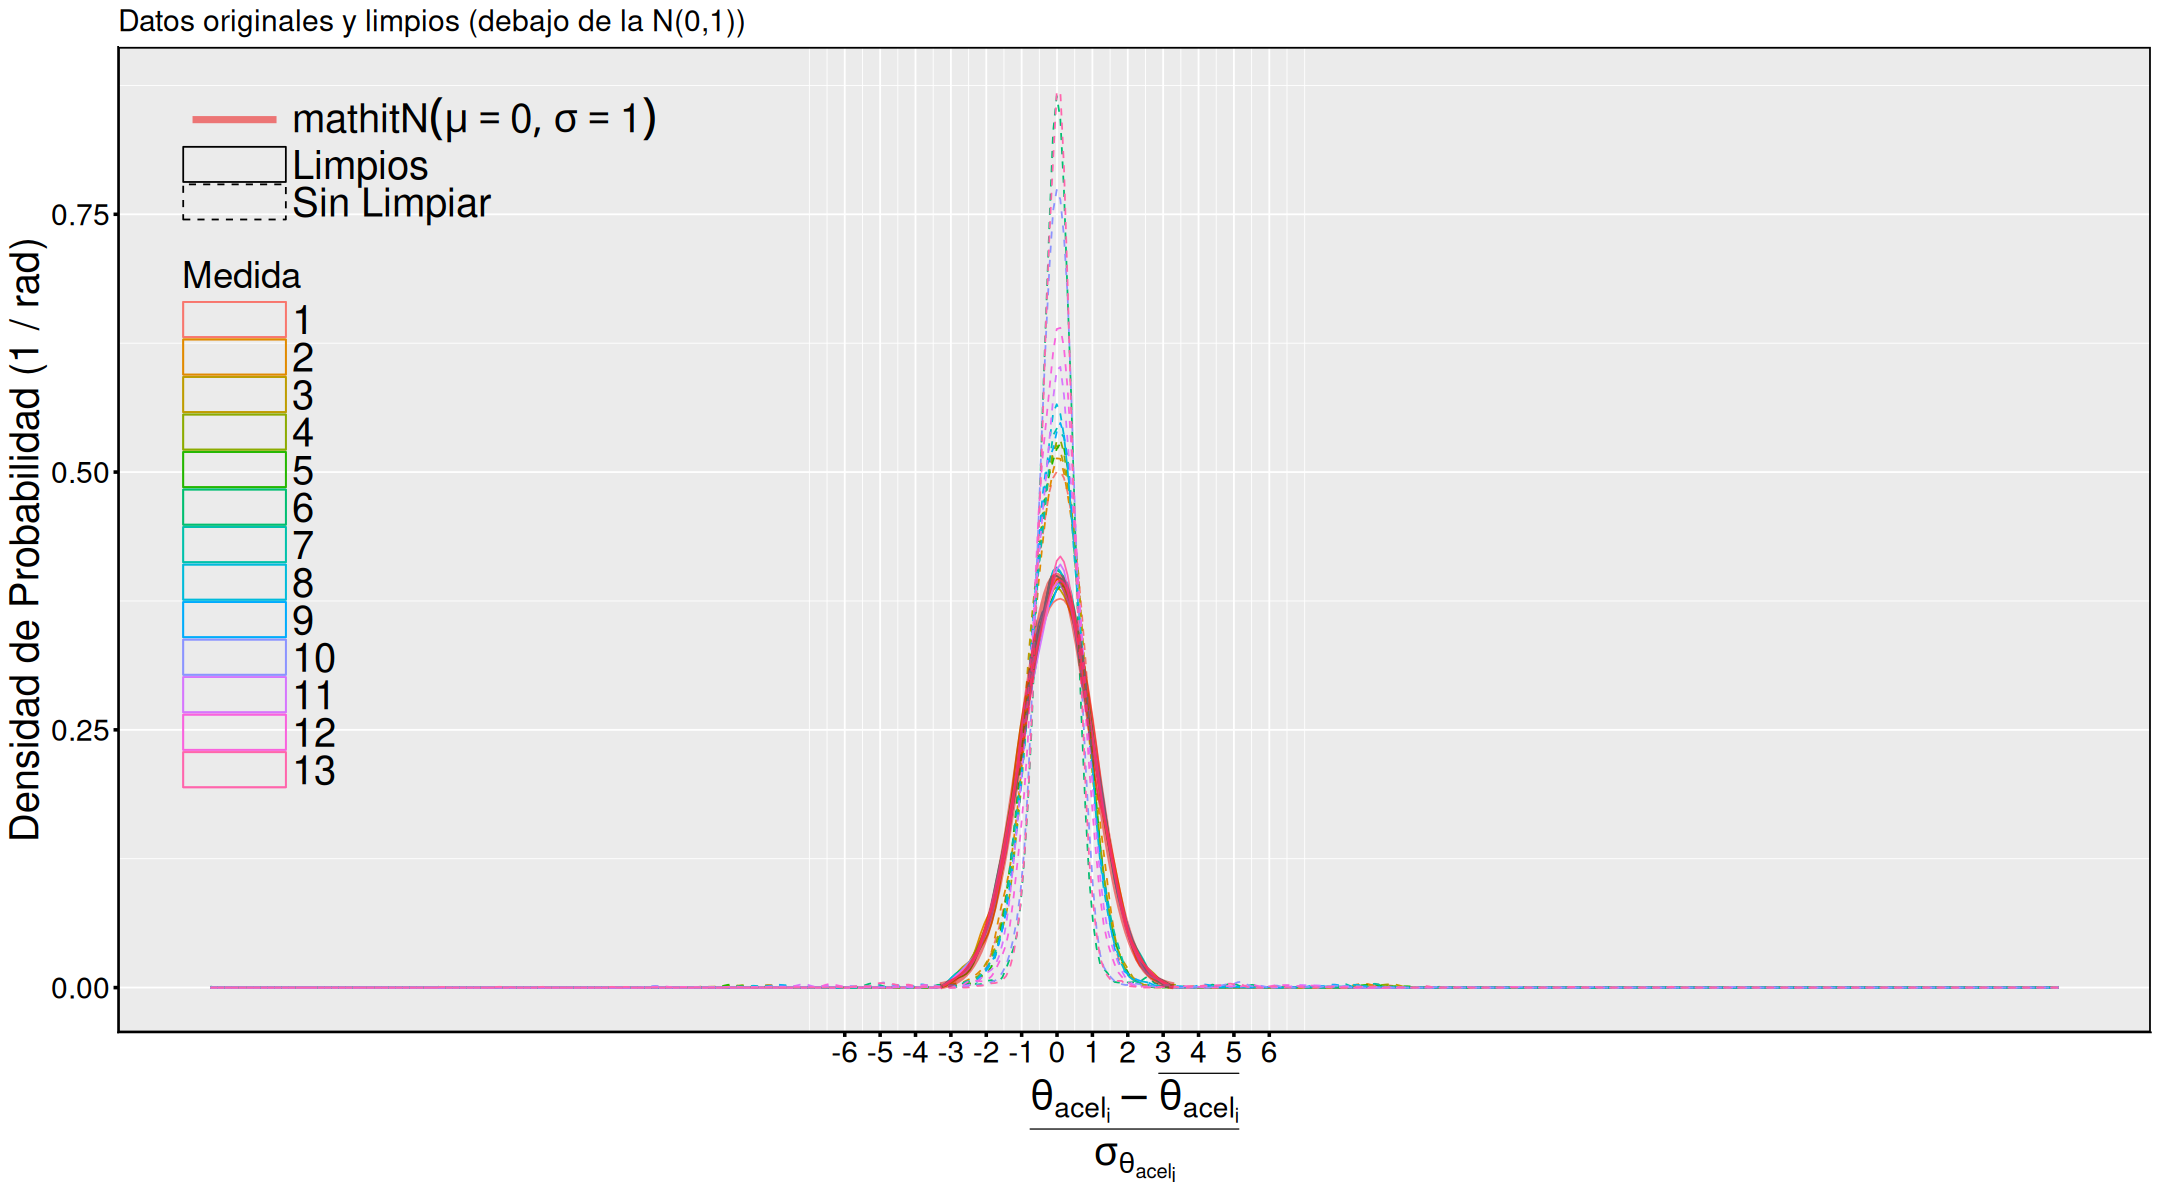

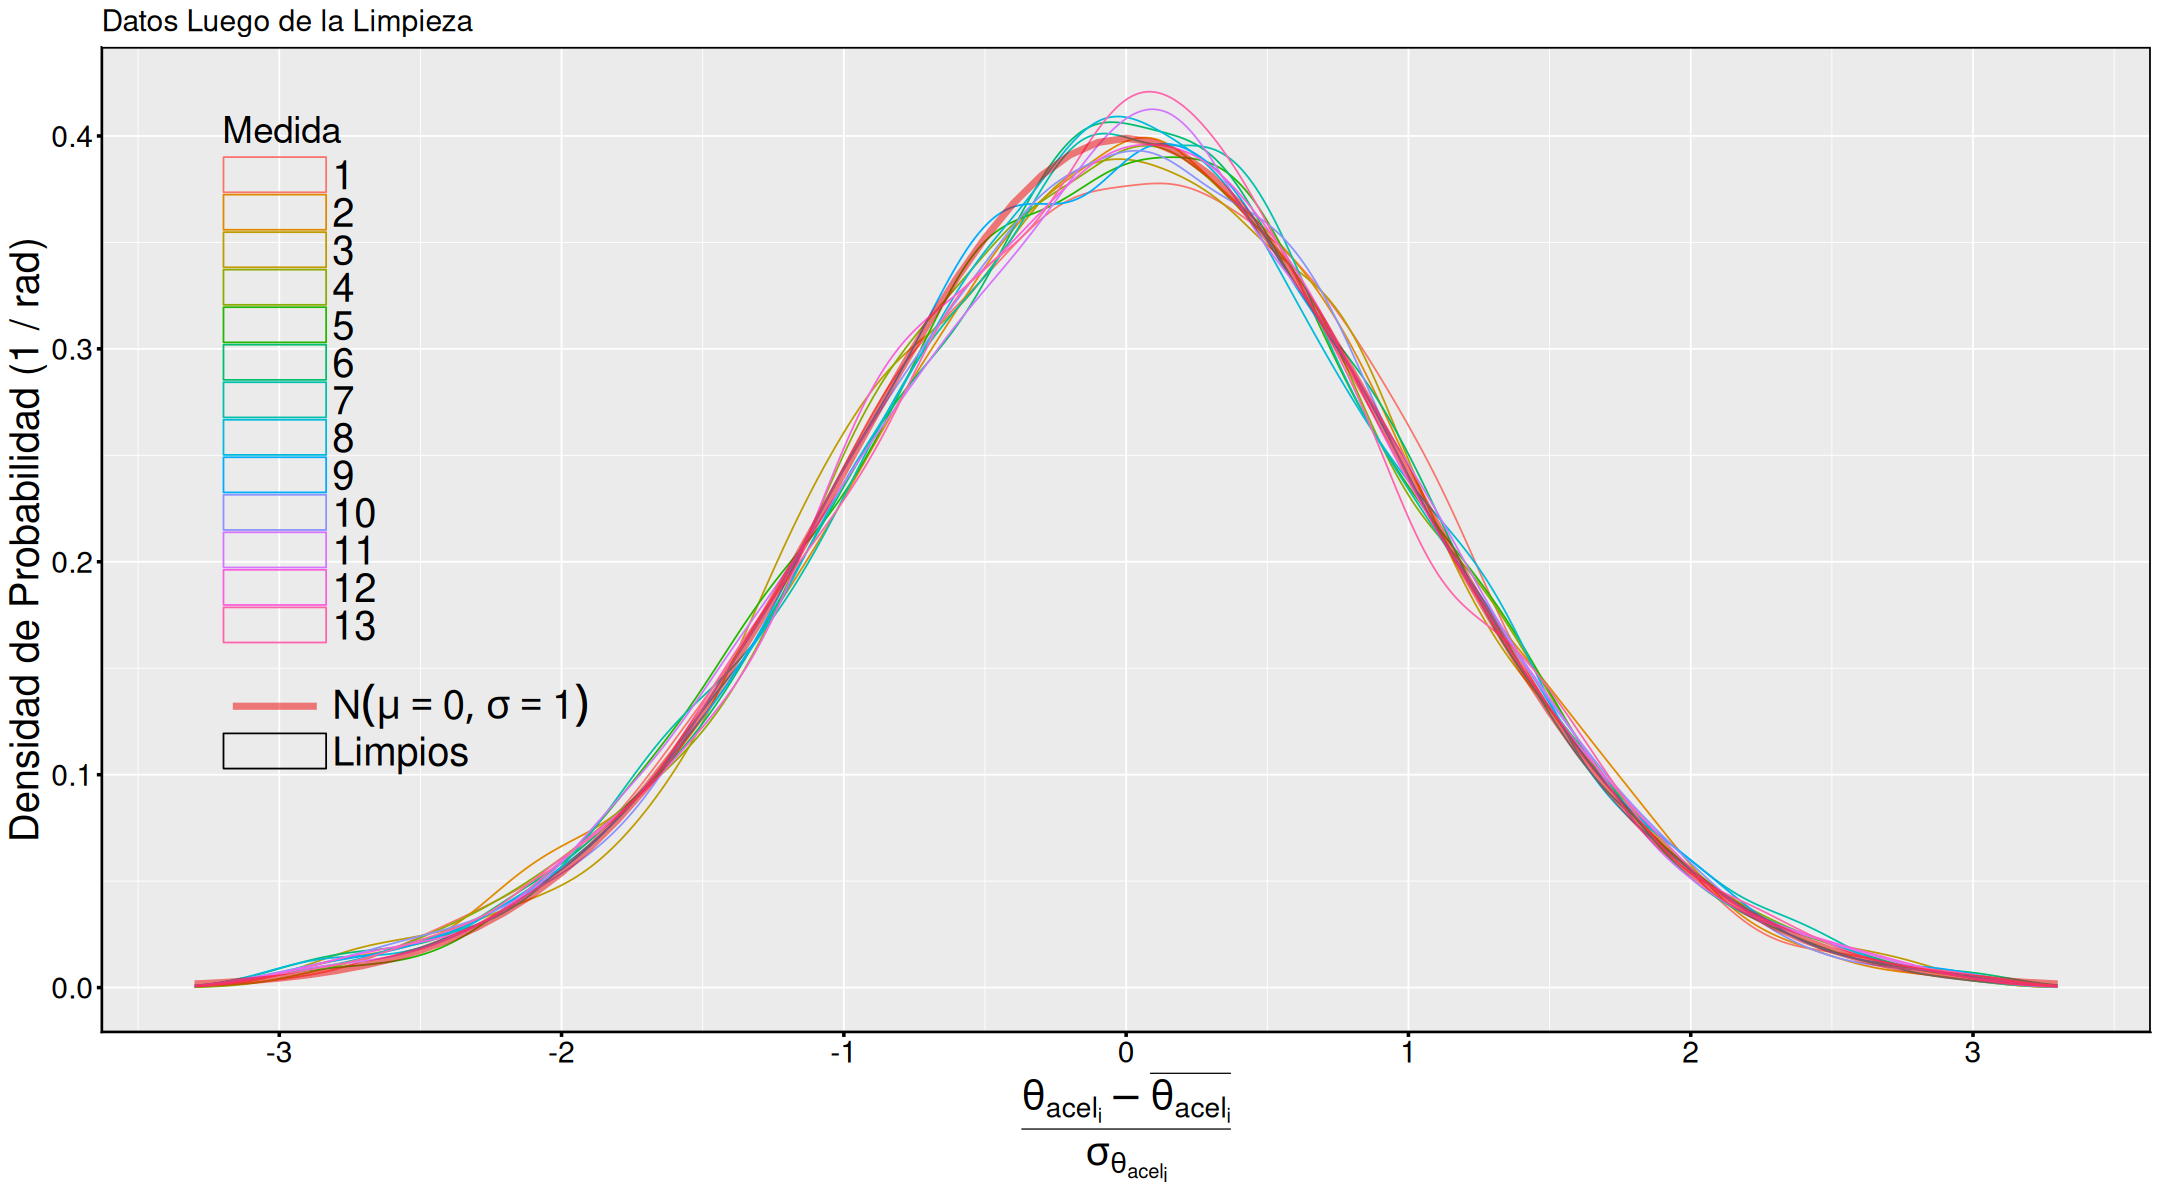

In [67]:
#graficamos originales y limpios
gtlimpio$Medida <- as.factor(gtlimpio$Medida) 
gt$Medida <- as.factor(gt$Medida) 

g <- ggplot() + 
geom_density(data = gtlimpio, aes(x = ang_acel_normalizado, colour = Medida ,group = Medida, lty = "Limpios" ), alpha = 0.2 ) + 
geom_density(data = gt, aes(x = ang_acel_normalizado, colour = Medida ,group = Medida, lty = "Sin Limpiar" ), alpha = 0.2 ) + 
geom_line(data = pdfn, aes(x = x, y = pdf, lty = "DN"), col = "Red2", alpha = 0.5, lwd = 2) + 
scale_linetype_manual(name = NULL,breaks = c("DN", "Limpios", "Sin Limpiar"), values = c(1,1,2), labels = list(TeX("$\\mathit{N} (\\mu = 0, \\sigma = 1)$"), "Limpios", "Sin Limpiar" )) + 
scale_x_continuous(breaks = seq(-6,6,1), labels = seq(-6,6,1)) +
temajuan + theme(legend.position = c(0.15,0.6), legend.box = "vertical", legend.direction = "vertical") +
ggtitle("Datos originales y limpios (debajo de la N(0,1))") +
ylab("Densidad de Probabilidad (1 / rad)") + 
xlab(TeX("$\\frac{\\theta_{acel_i} - \\bar{\\theta_{acel_i} } }{\\sigma_{\\theta_{acel_i}} }$"))

g2 <- ggplot() + 
geom_density(data = gtlimpio, aes(x = ang_acel_normalizado, colour = Medida ,group = Medida, lty = "Limpios" ), alpha = 0.2 ) + 
geom_line(data = pdfn, aes(x = x, y = pdf, lty = "DN"), col = "Red2", alpha = 0.5, lwd = 2) + 
scale_linetype_manual(name = NULL,breaks = c("DN", "Limpios", "Sin Limpiar"), values = c(1,1,2), labels = list(TeX("$N (\\mu = 0, \\sigma = 1)$"), "Limpios", "Sin Limpiar" )) + 
scale_x_continuous(breaks = seq(-6,6,1), labels = seq(-6,6,1)) +
temajuan + theme(legend.position = c(0.15,0.6), legend.box = "vertical", legend.direction = "vertical") +
ggtitle("Datos Luego de la Limpieza") +
ylab("Densidad de Probabilidad (1 / rad)") + 
xlab(TeX("$\\frac{\\theta_{acel_i} - \\bar{\\theta_{acel_i} } }{\\sigma_{\\theta_{acel_i}} }$"))

show(g)
show(g2)

Digamos que el método limpió bien:
* Las densidades de cada medida le re pegan a la distribución canónica.
* las posibles desviaciones son muy chiquititas y el ancho de todas es igualito.


Este gráfico no es para mostrarlo en la presentación, es sólo corroboración del método!

Hay otros métodos similares.

Este método asume que:

* Hay pocos valores anómalos comparados con el total de valores.

* La distribución que queremos encontrar es simétrica (limpiamos igual a derecha e izquierda).

* 3 desviaciones estándar a cada lado agarran 99.7% de los datos que queremos (v.s., es una distribución normal).

## Calibración con datos limpios

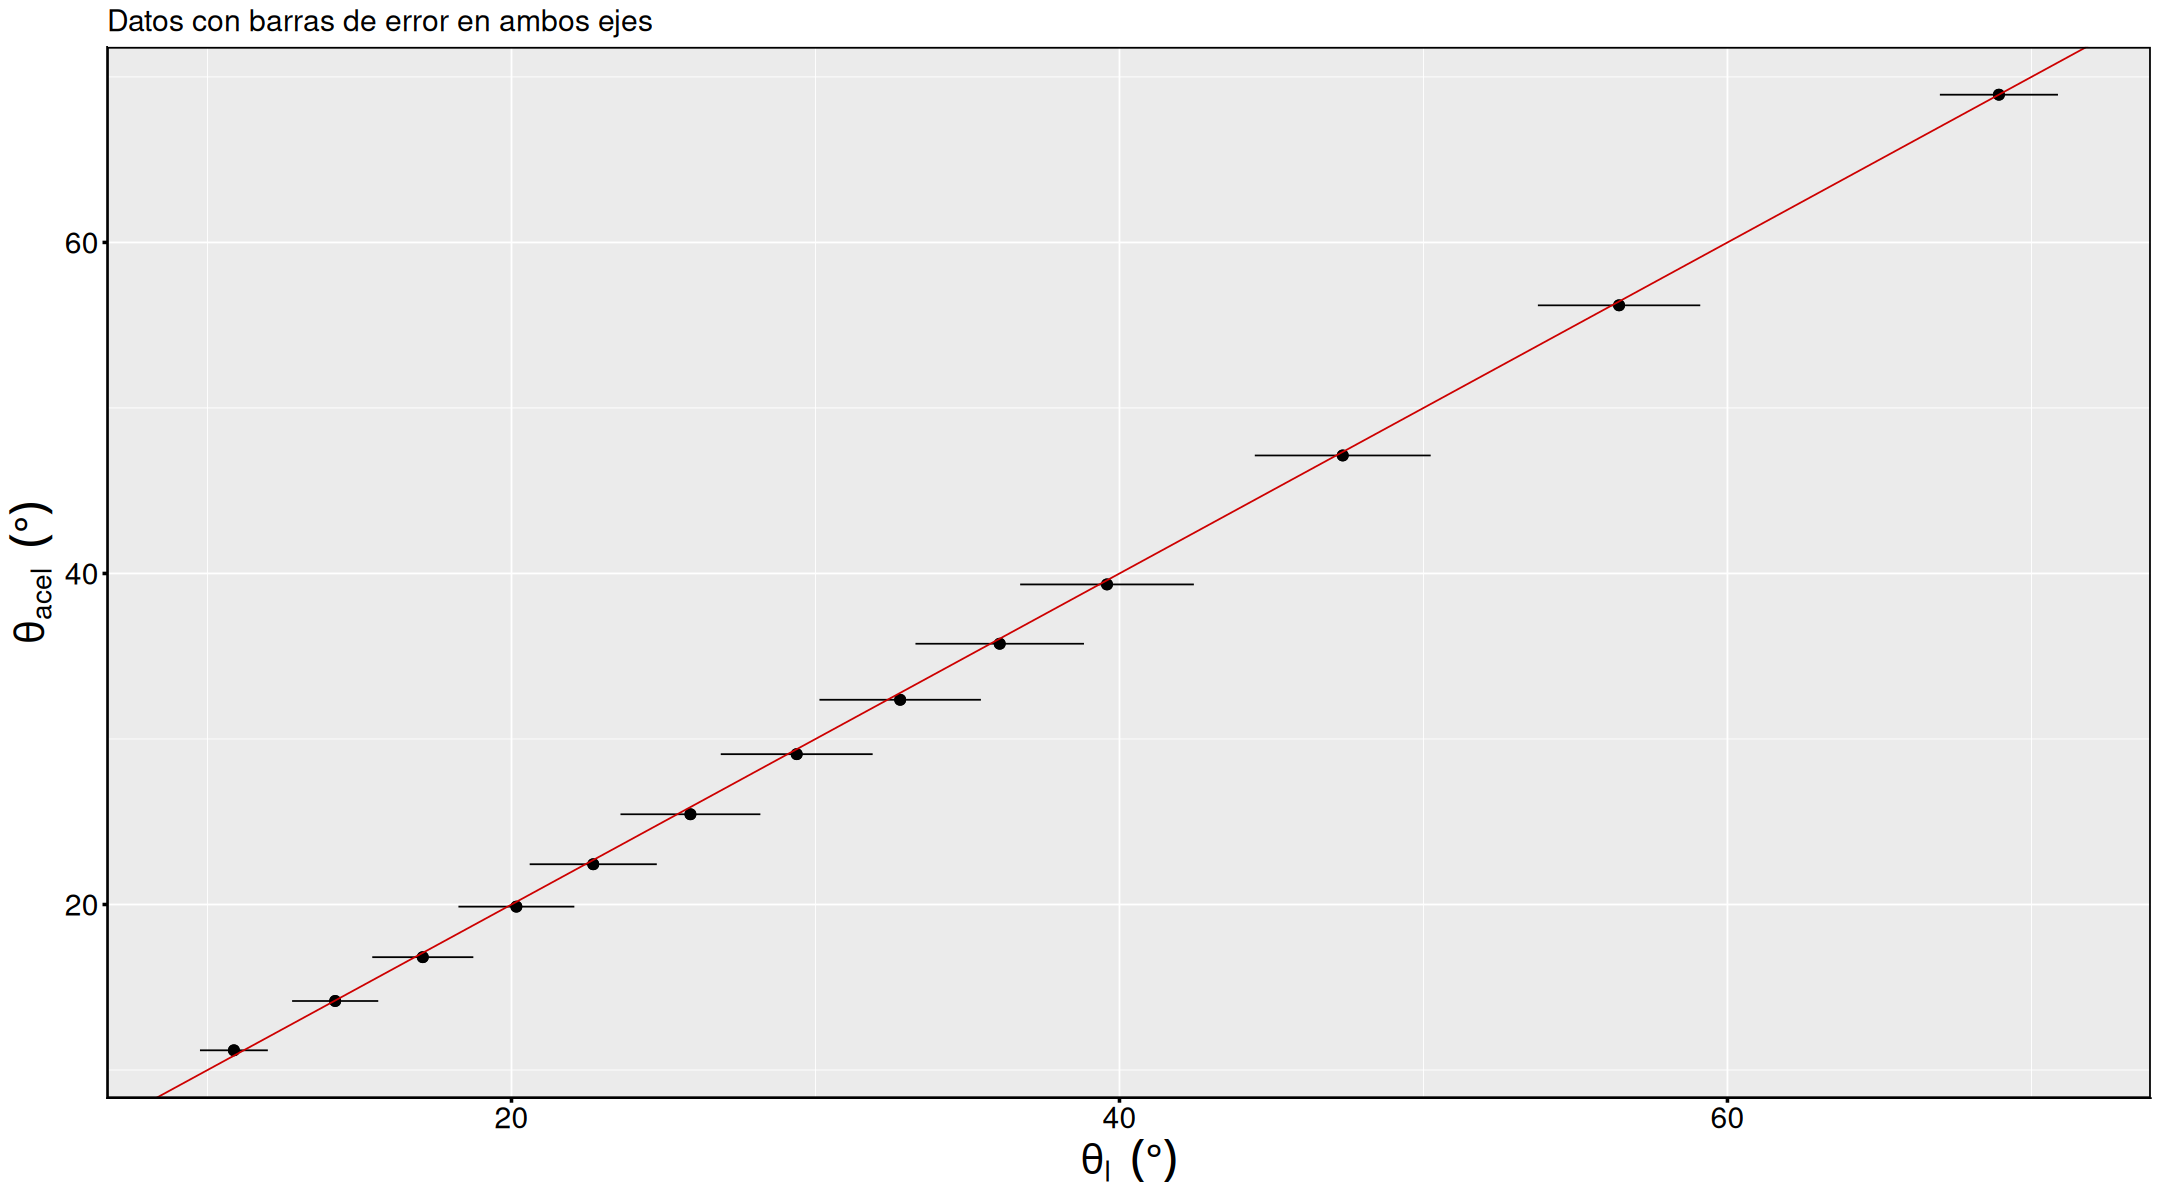

In [86]:
#Graficamos con barras de error
ga <- ggplot(data = dn) + 
geom_pointrange(aes(x = theta_cat, y = theta_acel, ymin = theta_acel - 3*sem_acel, ymax = theta_acel + 3*sem_acel)) + 
geom_pointrange(aes(x = theta_cat, y = theta_acel, xmin = theta_cat - dtheta_cat, xmax = theta_cat + dtheta_cat)) + 
geom_abline(aes(intercept = 0, slope = 1), colour = "Red3") + 
ggtitle("Datos con barras de error en ambos ejes") + 
xlab(TeX("$\\theta_{l} \\; (\\degree)$")) + 
ylab(TeX("$\\theta_{acel} \\; (\\degree)$")) + 


temajuan
show(ga)

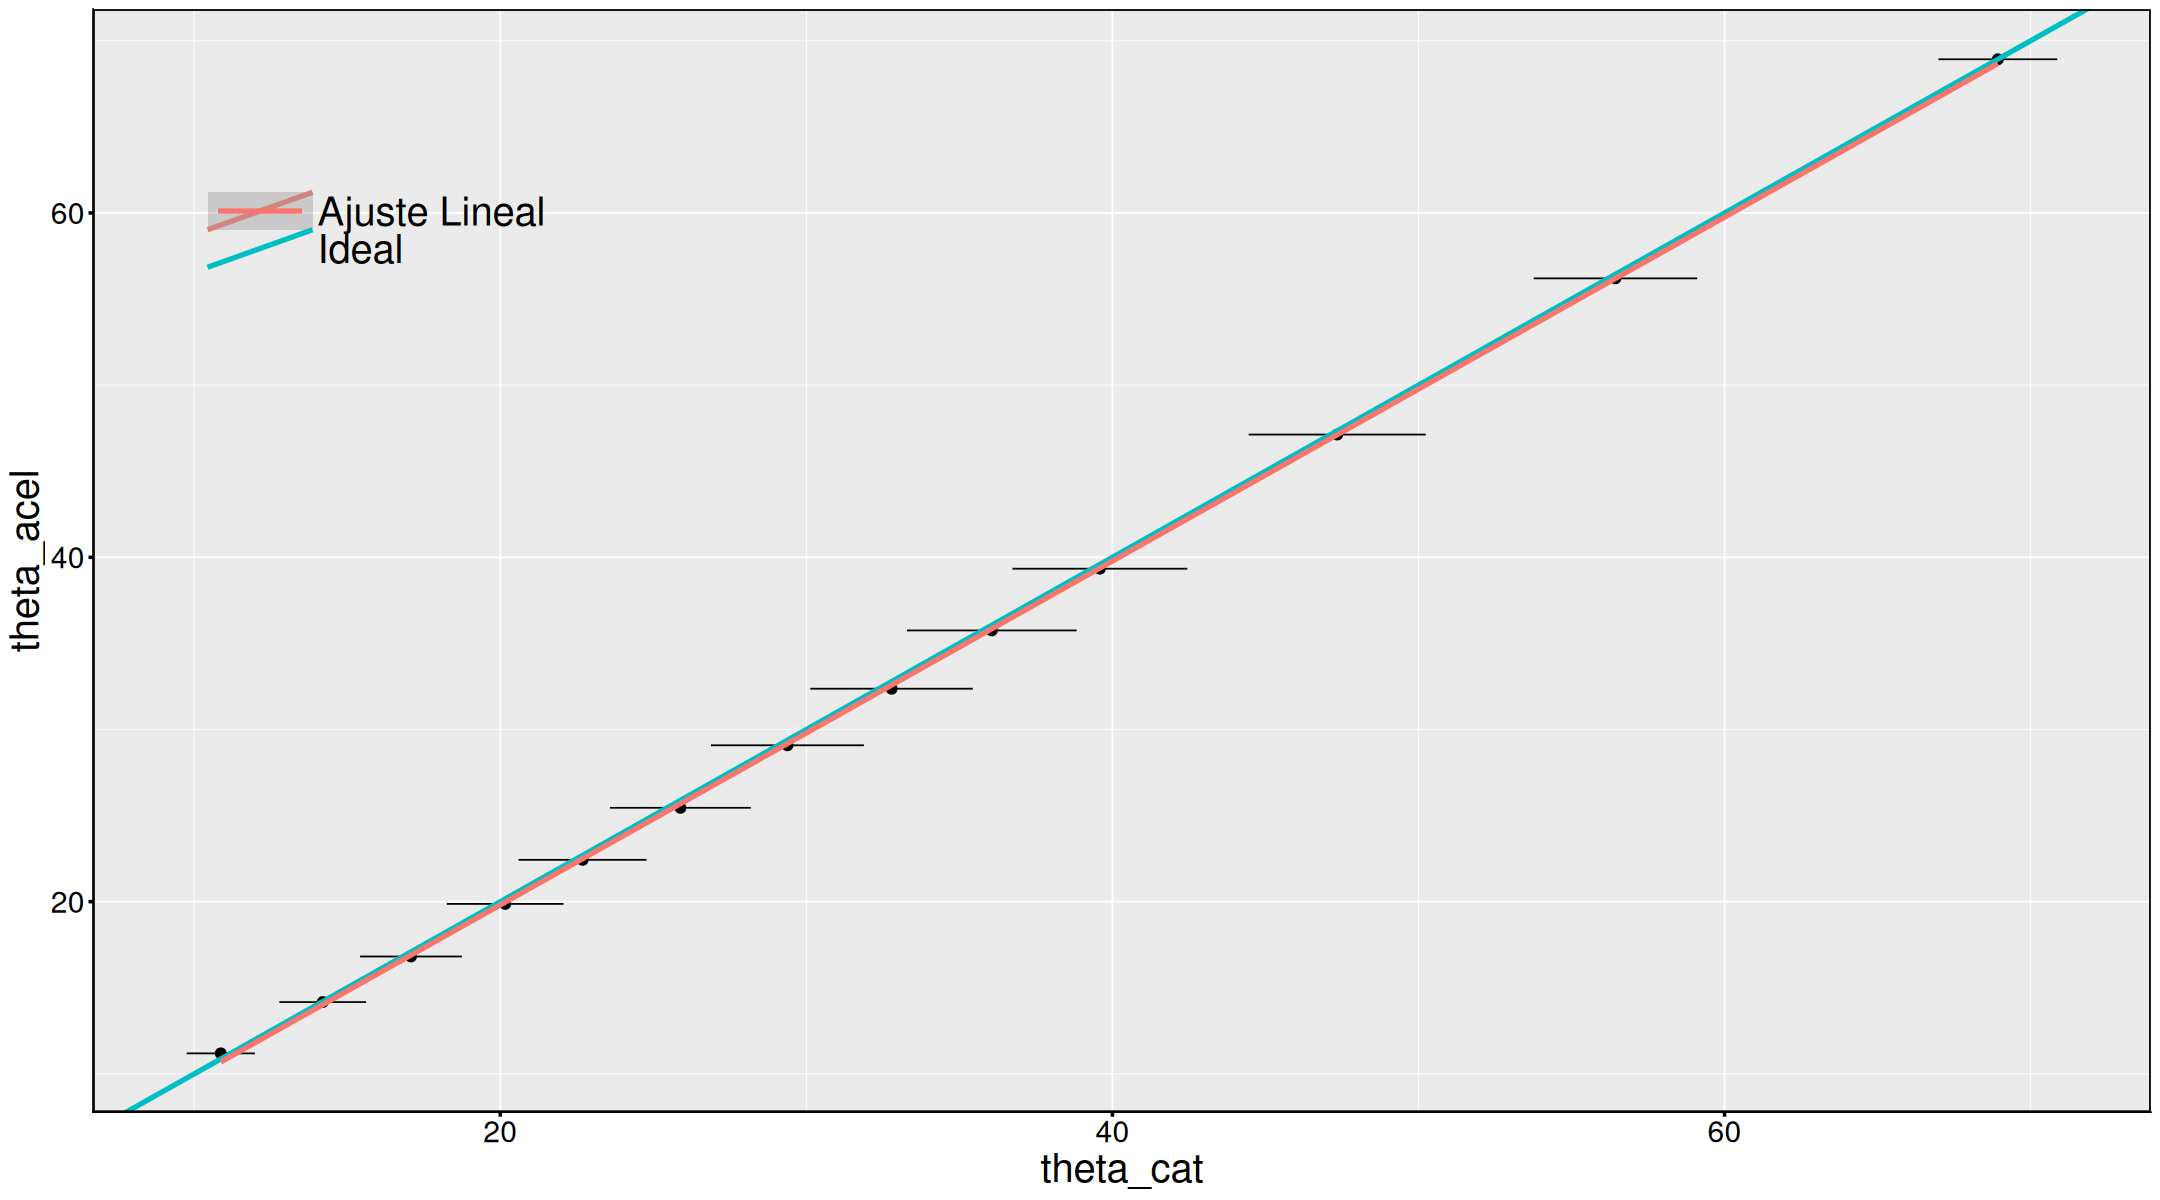

In [75]:
#graficamos de nuevo con datos limpios
gangulosclean <- ggplot() + 
geom_pointrange(aes(x = theta_cat, y = theta_acel, xmin = theta_cat - dtheta_cat, xmax = theta_cat + dtheta_cat)) + 
geom_abline(aes(intercept = 0, slope = 1, colour = "Ideal"), lwd = 1.5,show.legend = T) +
geom_smooth(data = gtlimpio, aes(x = ang_cat, ang_acel, colour = "Ajuste Lineal"), 
            lwd = 1.5,method = "lm", formula = "y ~ x", fullrange = F) + 
#scale_colour_manual(breaks = c("Ideal", "Ajuste Lineal"), values = c("Red","DeepSkyBlue4") ) + 
temajuan + theme(legend.direction = "vertical", legend.box = "vertical", legend.title = element_blank())

show(gangulosclean)


Vemos que la incerteza de los ángulos es grande en el método de los catetos, comparada con la del acelerómetro.

In [76]:
#valores ajustes
ablimpio <- lm(gtlimpio$ang_acel ~ gtlimpio$ang_cat); rablimpio <- summary.lm(ablimpio)
rab$coefficients
rablimpio$coefficients

cat(bold("\n\n R^2_original = ", rab$adj.r.squared, "\n R^2_limpio   = ", rablimpio$adj.r.squared))

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-0.1631715,1.932846e-03,-84.42034,0
gt$ang_cat,0.9986717,5.315867e-05,18786.61905,0


,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),-0.1626714,1.765050e-03,-92.16249,0
gtlimpio$ang_cat,0.9986494,4.861088e-05,20543.74329,0




 R^2_original =  0.999810897224209 
 R^2_limpio   =  0.99984438456128

Una moraleja: Hay tantos datos que los estimadores no mejoran *muchísimo* (aunque mejoran un poco).

Sin embargo, si hubiéramos tenido datos anómalos sesgados sólo para un lado, el método hubiera funcionado igual y los estimadores hubieran mejorado considerablemente.

## Viendo $\delta \theta = \theta_l - \theta_a$

Veamos cómo quedaron los sesgos.

In [77]:
#calculamos diferencia
dn$dtheta <- dn$theta_cat - dn$theta_acel

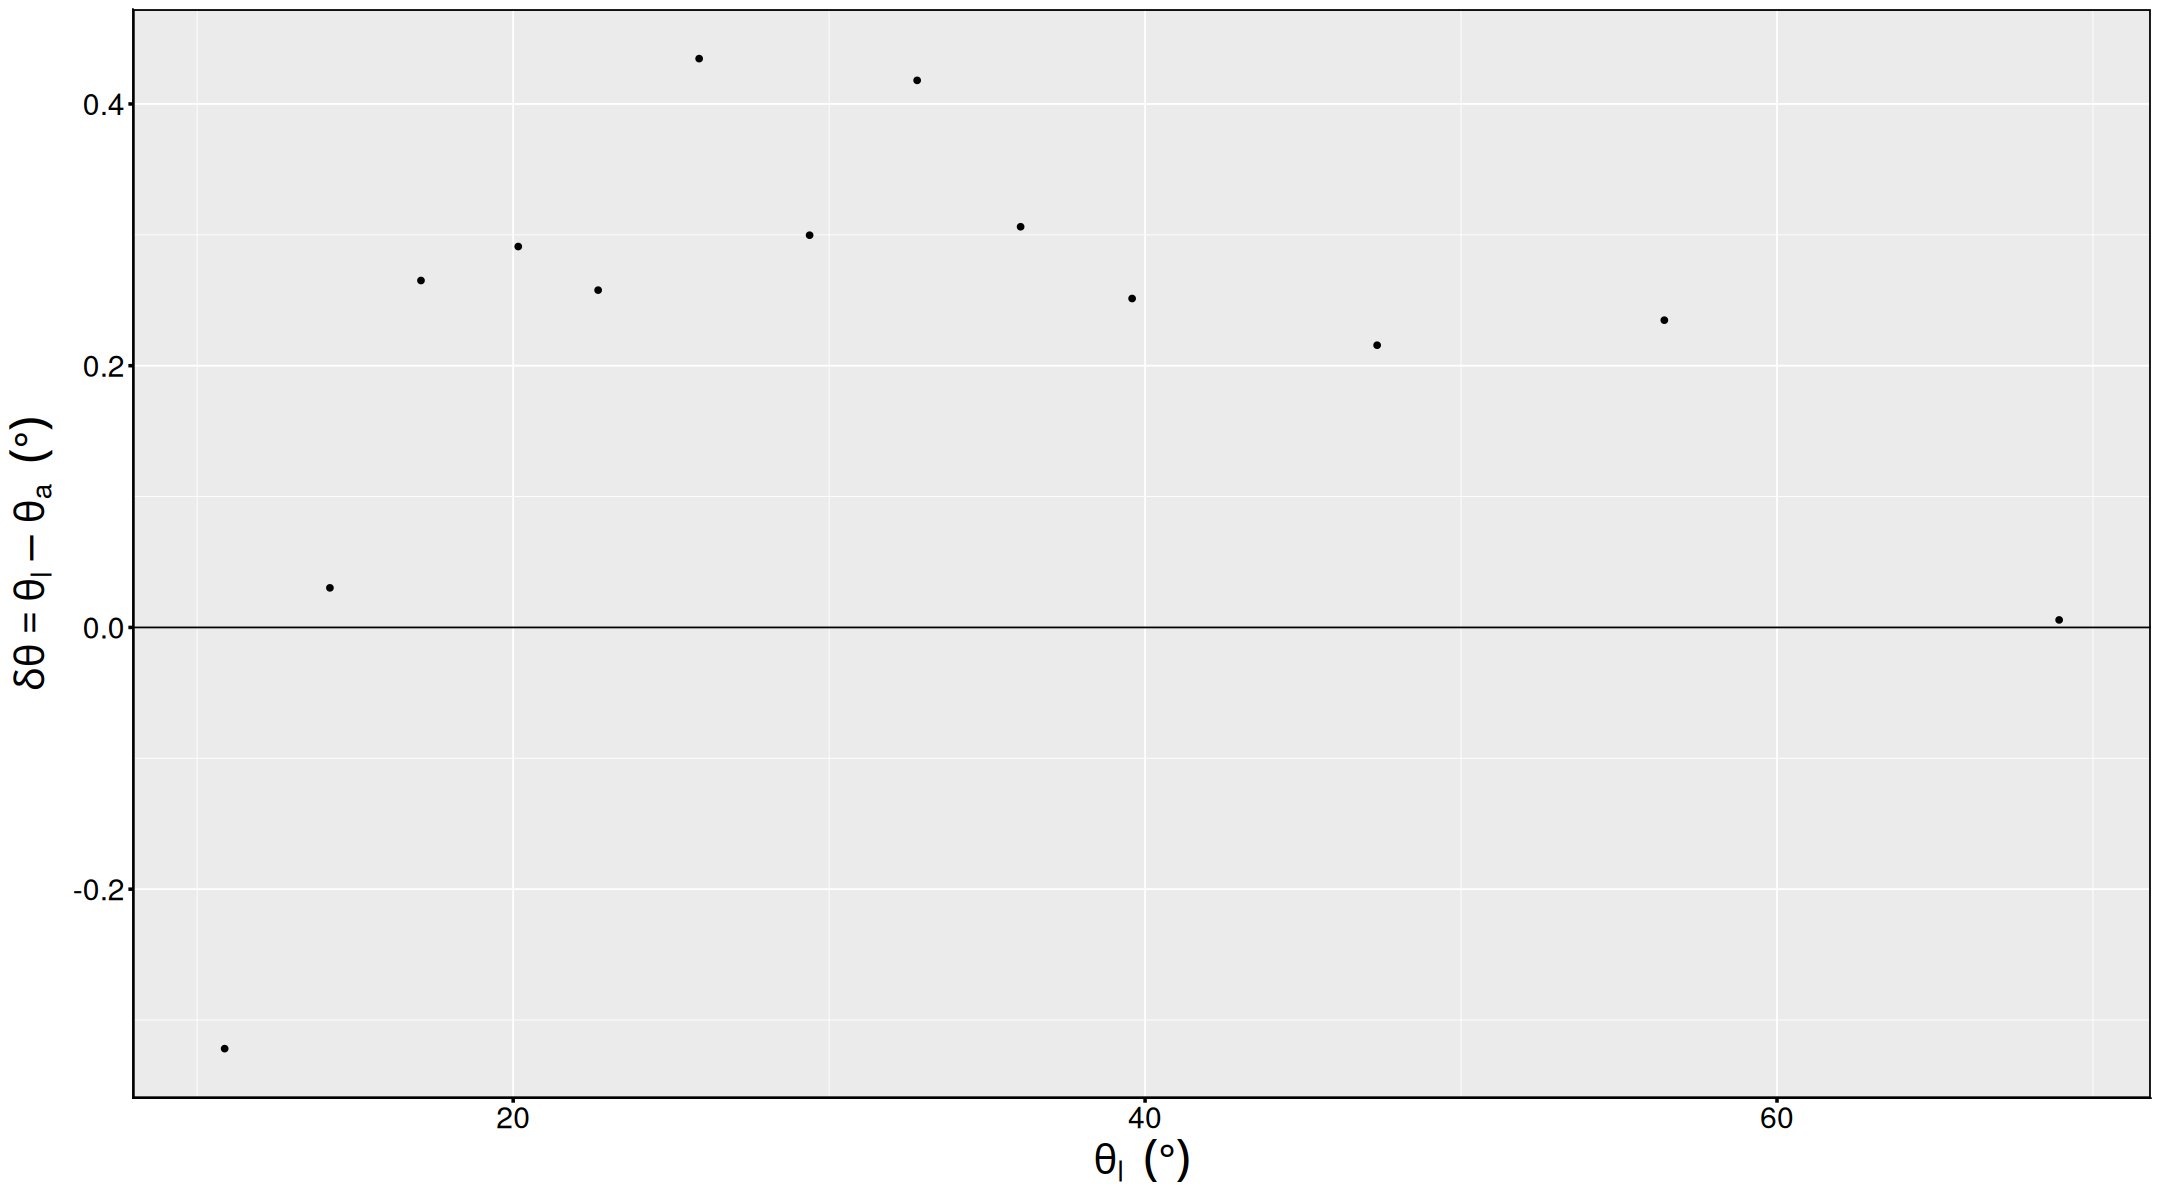

In [85]:
#ploteamos
gd <- ggplot(data = dn) + 
geom_point(aes(x = theta_cat, y = dtheta)) + 
geom_hline(aes(yintercept = 0)) + 
ylab(TeX("$\\delta \\theta = \\theta_l - \\theta_a \\; (\\degree)$")) + 
xlab(TeX("$\\theta_l \\; (\\degree)$")) + 
temajuan
show(gd)